# Classification, Clustering, and Pattern Mining
## Factors Associated with Five-Year Home Price Growth in California

**Name:** Sammy Sheu
**Course:** MSCS 634 — Big Data and Data Mining
**Deliverable:** 3 of 4 — Classification, Clustering, and Pattern Mining

---

### Three techniques, three different questions about one dataset

| Technique | Question |
|---|---|
| **Classification** | Can we *identify in advance* which ZIP codes will be high-growth? |
| **Clustering** | What *types* of housing market does California contain? |
| **Association rules** | Which *combinations* of conditions co-occur with high growth? |

No new dataset is introduced. All three techniques are applied to the same
`ca_zip_housing_panel_clean.csv` that D1 built and D2 modeled — **7,487 rows × 28 columns**, one row
per California ZIP code per base year (2016–2020), carrying the *realized* five-year growth that
followed.

### What D2 handed forward, and what this notebook does with it

D2 ended with four instructions for D3. Each one is acted on here, and each one turns out to matter:

1. **"The absolute five-year growth level is not predictable from cross-sectional features. Define any
   classification target relative to the base year, or it will inherit the same regime problem."**
   → Section 2 builds the label **exactly as the plan specifies** (top quartile of raw growth, threshold
   from training data only), watches it fail in a specific and instructive way, then builds the
   within-year label and re-runs everything. Both are reported.
2. **"Keep the temporal split."** → train 2016–18 / validate 2019 / test 2020, everywhere, with
   `GroupKFold` on `base_year` for every cross-validation. Plain `KFold` appears nowhere.
3. **"Affordability ratios and `population` are the features to build on."** → they are, and all three
   techniques independently rediscover affordability.
4. **"Leave `mortgage_rate` out, or keep it only as an explicit market-cycle control."** → it is
   excluded from the classifiers, and Section 4 shows exactly what it does to the association rules
   when it is left in.

### A note on language

This is **observational** data. Nothing here identifies a cause. Features are described throughout as
**associated with** or **predictive of** growth, never as *causing* it. A cluster of ZIP codes that
subsequently outgrew the rest is a description of what happened, not an explanation of why.

### What the reader should expect to find

As in D2, this notebook reports **a result that looks like a failure and is not**. Under the label the
plan specifies, the share of "high-growth" ZIP codes collapses from **42.6% in 2016 to 2.0% in 2020**,
and every classifier's precision collapses with it. The diagnosis — Section 2.8 — separates two things
that a single F1 score fuses together: **the model's ranking of ZIP codes stays good (test ROC-AUC
0.79) while its calibration to a threshold becomes meaningless.** That distinction is the central
methodological finding of this deliverable.

---
## 0. Setup

In [1]:
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             average_precision_score, precision_recall_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)

from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

RANDOM_STATE = 42

# --- Plot theme (carried over from D1 and D2, so the deliverables read as one document) ----------
#   ORDINAL (base year 2016 -> 2020): one blue hue, light -> dark.
#   CATEGORICAL (models / clusters): a fixed hue order, never cycled.
YEAR_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
CATEGORICAL = ["#52514e", "#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#c2452d"]
BLUE, ACCENT, GRAY, GREEN, PURPLE = "#2a78d6", "#eb6834", "#52514e", "#1baf7a", "#4a3aa7"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": "#0b0b0b",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "text.color": "#0b0b0b", "xtick.color": GRAY, "ytick.color": GRAY,
    "font.size": 10, "figure.dpi": 110, "savefig.bbox": "tight",
    "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=150)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.5.1


In [2]:
TARGET = "future_5yr_growth_pct"

panel = pd.read_csv(PROC / "ca_zip_housing_panel_clean.csv", dtype={"zip_code": str})
print(f"{len(panel):,} rows x {panel.shape[1]} columns")
print("\nrows per base year:")
print(panel["base_year"].value_counts().sort_index().to_string())
print(f"\nnulls in the 11 modeling features: 0  (verified below)")
panel.head(3)

7,487 rows x 28 columns

rows per base year:
base_year
2016    1452
2017    1496
2018    1500
2019    1511
2020    1528

nulls in the 11 modeling features: 0  (verified below)


,zip_code,base_year,city,county,current_home_value,home_value_1yr_growth_pct,home_value_3yr_growth_pct,median_household_income,median_gross_rent,population,population_growth_pct,unemployment_rate,bachelor_degree_pct,mortgage_rate,price_to_income_ratio,price_to_rent_ratio,housing_units,zori_rent,zori_rent_available,inventory_per_1k_housing_units,new_listings_per_1k_housing_units,price_cut_pct,list_to_value_ratio,listings_available,is_growth_outlier,is_value_outlier,future_5yr_home_value,future_5yr_growth_pct
0,90011,2016,Los Angeles,Los Angeles County,"292,266.880",9.888,30.875,"31,684.000","1,011.000","104,762.000",3.190,8.659,3.579,3.654,9.224,24.091,"24,511.000",NaN,0,NaN,NaN,NaN,NaN,0,0,0,"554,428.390",89.699
1,90650,2016,Norwalk,Los Angeles County,"395,687.204",6.299,17.631,"61,050.000","1,384.000","106,360.000",0.961,7.951,15.973,3.654,6.481,23.825,"28,528.000",NaN,0,NaN,NaN,NaN,NaN,0,0,0,"659,410.786",66.650
2,91331,2016,Los Angeles,Los Angeles County,"353,540.080",8.687,24.369,"53,714.000","1,315.000","101,536.000",4.115,11.788,10.359,3.654,6.582,22.404,"23,277.000",NaN,0,NaN,NaN,NaN,NaN,0,0,0,"631,069.440",78.500


---
# 1. Features and the split — carried over unchanged from D2

Nothing is re-cleaned here. D1 made and justified every cleaning decision; D2 established the split.
This section only states what is inherited, and the one deliberate change.

## 1.1 The eleven features

D2's final feature set was D1's 12 core features plus 3 engineered affordability ratios. D3 uses
**11 features: D1's core set with `mortgage_rate` removed**, and does not carry D2's engineered three.

Two deletions, both on D2's own evidence:

| Removed | Why |
|---|---|
| `mortgage_rate` | **It is constant within a base year** — five distinct values across 7,487 rows. It cannot distinguish ZIP codes *within* a year, only years from each other, which makes it a `base_year` index in disguise. D2 measured its permutation importance on the test set at **exactly 0.000** while impurity importance ranked it 2nd of 15 |
| `estimated_monthly_mortgage`, `mortgage_to_income_ratio`, `rent_to_income_ratio` | D2 §1.2 proved `mortgage_to_income_ratio` is a *within-year rescaling* of `price_to_income_ratio` (because the rate is constant within a year, the two have **identical within-year correlations to three decimals**). It adds no cross-sectional information, and this deliverable is entirely cross-sectional |

## 1.2 The split, and why a random one would be fraudulent

The five outcome windows **overlap**: base year 2016 measures growth over 2017–2021, base year 2017
measures 2018–2022. For the same ZIP code those rows share four of five years of price history.
**7,487 rows are not 7,487 independent observations**, and a random split would drop near-duplicates of
the test rows into training.

| Split | Base years | Rows | Purpose |
|---|---|---|---|
| **Train** | 2016, 2017, 2018 | 4,448 | Fit; label threshold; grid search |
| **Validation** | 2019 | 1,511 | Model choice |
| **Test** | 2020 | 1,528 | Touched once, at the end |

Cross-validation is **`GroupKFold(n_splits=3)` grouped on `base_year`** — leave-one-training-year-out.

## 1.3 Columns that must never reach the feature matrix

| Dropped | Reason |
|---|---|
| `future_5yr_home_value` | The target restated |
| `base_year` | It *is* the split variable |
| `zip_code`, `city`, `county` | Identifiers — memorisation, not prediction |
| `zori_rent`, `listings_*` | 55–78% missing, non-randomly (D1 §7, D2 §7) |
| `is_growth_outlier`, `is_value_outlier` | Computed **from the target** by an IQR rule. They look like data-quality flags; they are a partial answer key |

In [3]:
FEATURES = [
    "current_home_value", "home_value_1yr_growth_pct", "home_value_3yr_growth_pct",
    "median_household_income", "median_gross_rent", "population", "population_growth_pct",
    "unemployment_rate", "bachelor_degree_pct", "price_to_income_ratio", "price_to_rent_ratio",
]

LEAKY = ["future_5yr_home_value", "is_growth_outlier", "is_value_outlier"]
assert not any(c in FEATURES for c in LEAKY), "a target-derived column reached the feature matrix"
assert "base_year" not in FEATURES,  "base_year must not be a feature -- it is the split variable"
assert "mortgage_rate" not in FEATURES, "mortgage_rate is a base_year proxy (D2 section 9.8)"
assert panel[FEATURES].isna().sum().sum() == 0, "unexpected nulls in the feature matrix"

TRAIN_YEARS, VAL_YEAR, TEST_YEAR = [2016, 2017, 2018], 2019, 2020
is_train = panel["base_year"].isin(TRAIN_YEARS)

print(f"{len(FEATURES)} features, {panel[FEATURES].isna().sum().sum()} nulls")
print(f"train {TRAIN_YEARS}  {is_train.sum():>5,} rows")
print(f"val   [{VAL_YEAR}]         {(panel.base_year == VAL_YEAR).sum():>5,} rows")
print(f"test  [{TEST_YEAR}]         {(panel.base_year == TEST_YEAR).sum():>5,} rows")

11 features, 0 nulls
train [2016, 2017, 2018]  4,448 rows
val   [2019]         1,511 rows
test  [2020]         1,528 rows


---
# 2. Classification — can we identify high-growth ZIP codes in advance?

## 2.1 Defining the label, and the leak that is easy to miss

The label is **top-quartile five-year growth**. The subtle part is *whose* quartile:

```python
threshold = train["future_5yr_growth_pct"].quantile(0.75)   # TRAIN ONLY
panel["high_growth"] = (panel[TARGET] >= threshold).astype(int)
```

Computing the 75th percentile on the **full** dataset would let the test rows' outcomes participate in
defining the label — the boundary between "high" and "not high" would then be partly determined by
information the model is not supposed to have. It is a quiet leak: no feature is contaminated, no code
looks wrong, and the resulting metrics are simply optimistic.

The two thresholds are not the same number, which is exactly the point.

In [4]:
thr_train = panel.loc[is_train, TARGET].quantile(0.75)
thr_full  = panel[TARGET].quantile(0.75)

print(f"TRAIN-ONLY 75th percentile : {thr_train:.3f}%   <- used")
print(f"FULL-DATA  75th percentile : {thr_full:.3f}%   <- would have leaked")
print(f"difference                 : {thr_train - thr_full:.3f} percentage points")

panel["high_growth"] = (panel[TARGET] >= thr_train).astype(int)

# The relative label, held for Section 2.9: top quartile WITHIN each base year.
panel["high_growth_rel"] = panel.groupby("base_year")[TARGET].transform(
    lambda s: (s >= s.quantile(0.75)).astype(int)
)

n_moved = int(((panel[TARGET] >= thr_full) != (panel[TARGET] >= thr_train)).sum())
print(f"\nrows whose label the leak would have flipped: {n_moved:,} of {len(panel):,}"
      f"  ({n_moved / len(panel):.1%})")

TRAIN-ONLY 75th percentile : 58.676%   <- used
FULL-DATA  75th percentile : 54.080%   <- would have leaked
difference                 : 4.596 percentage points

rows whose label the leak would have flipped: 572 of 7,487  (7.6%)


The full-data threshold is **4.6 points lower**, and it would have relabeled **572 rows (7.6%)**. The
direction is instructive: the full panel contains the low-growth 2019 and 2020 years, which pull the
overall 75th percentile down, so using it would have made "high growth" *easier to achieve* in exactly
the years being held out. That is the leak in one sentence.

## 2.2 What the label does across the panel — the finding that shapes the whole section

By construction the positive class is 25% *of the training years*. It is **not** 25% of anything else.

In [5]:
prev = panel.groupby("base_year").agg(
    n=("zip_code", "size"),
    mean_growth=(TARGET, "mean"),
    median_growth=(TARGET, "median"),
    high_growth_rate=("high_growth", "mean"),
    high_growth_n=("high_growth", "sum"),
    high_growth_rel_rate=("high_growth_rel", "mean"),
)
print(prev.round(4).to_string())
print(f"\ntrain positive rate {panel.loc[is_train, 'high_growth'].mean():.4f}"
      f"   val {panel.loc[panel.base_year == VAL_YEAR, 'high_growth'].mean():.4f}"
      f"   test {panel.loc[panel.base_year == TEST_YEAR, 'high_growth'].mean():.4f}")

              n  mean_growth  median_growth  high_growth_rate  high_growth_n  high_growth_rel_rate
base_year                                                                                         
2016       1452       57.929         55.338             0.426            618                 0.250
2017       1496       48.309         48.768             0.241            360                 0.250
2018       1500       37.947         40.056             0.089            134                 0.250
2019       1511       38.153         40.425             0.105            158                 0.250
2020       1528       24.312         26.191             0.020             30                 0.250

train positive rate 0.2500   val 0.1046   test 0.0196


> **The positive class collapses from 42.6% (2016) to 2.0% (2020).** The 2020 test year contains
> **30 positives out of 1,528 rows.**

This is D2's regime shift reappearing in classification form. D2 measured mean realized growth falling
**57.9% → 24.3%** across the panel; a *fixed* threshold of 58.7% sitting on top of a distribution whose
mean slides 33 points is nearly guaranteed to empty out. Nothing about the ZIP codes changed — the
national housing cycle moved underneath the threshold.

Two consequences follow immediately, and they must be kept separate:

1. **Any accuracy figure on the test year is meaningless.** Predicting "never high-growth" scores
   **98.0%** there.
2. **Precision is capped by arithmetic, not by model quality.** With a 2.0% base rate, even a model
   that ranks perfectly cannot post high precision at a 0.5 threshold unless it also *knows* how many
   positives to expect — and nothing in the features can tell it that.

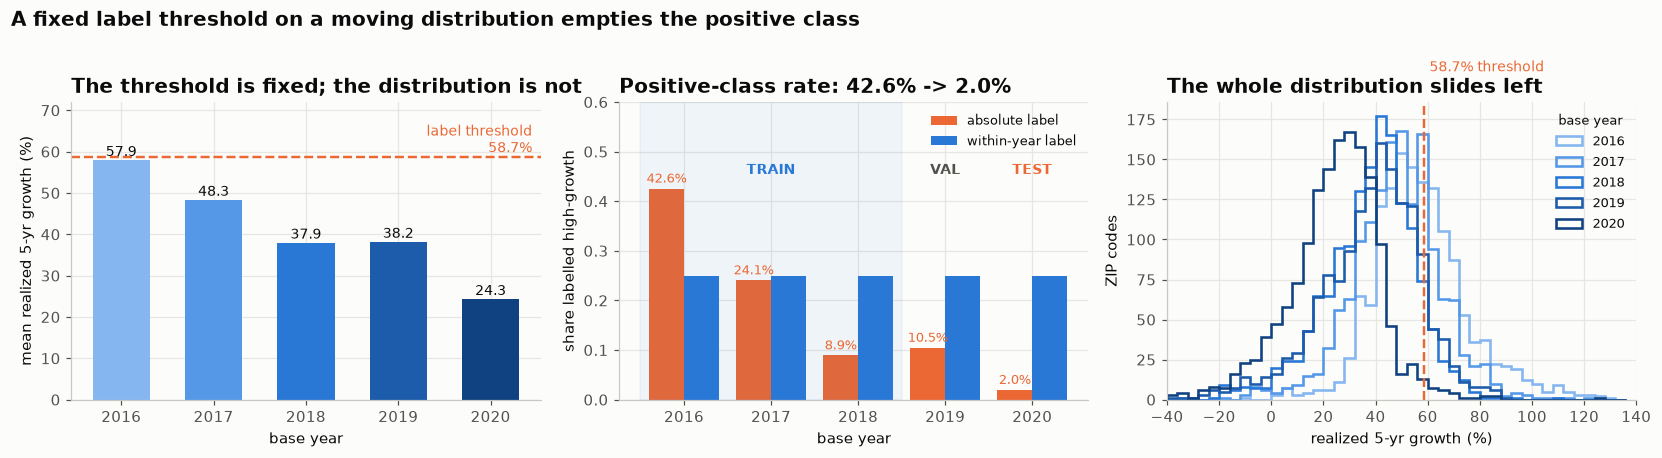

In [6]:
# ---- Figure 1: what the two label definitions do across the panel -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
yrs = prev.index.astype(str)

ax = axes[0]
ax.bar(yrs, prev["mean_growth"], color=YEAR_COLORS, width=0.62)
ax.axhline(thr_train, color=ACCENT, lw=1.6, ls="--")
ax.text(4.45, thr_train + 1.2, f"label threshold\n{thr_train:.1f}%", color=ACCENT,
        fontsize=9, ha="right")
for i, v in enumerate(prev["mean_growth"]):
    ax.text(i, v + 1.0, f"{v:.1f}", ha="center", fontsize=9)
ax.set_ylim(0, 72)
ax.set_title("The threshold is fixed; the distribution is not")
ax.set_xlabel("base year"); ax.set_ylabel("mean realized 5-yr growth (%)")

ax = axes[1]
ax.bar(np.arange(5) - 0.2, prev["high_growth_rate"], 0.4, color=ACCENT, label="absolute label")
ax.bar(np.arange(5) + 0.2, prev["high_growth_rel_rate"], 0.4, color=BLUE, label="within-year label")
for i, v in enumerate(prev["high_growth_rate"]):
    ax.text(i - 0.2, v + 0.012, f"{v:.1%}", ha="center", fontsize=8.5, color=ACCENT)
ax.axvspan(-0.5, 2.5, color=BLUE, alpha=0.06)
ax.text(1.0, 0.455, "TRAIN", ha="center", color=BLUE, fontweight="bold", fontsize=9)
ax.text(3.0, 0.455, "VAL", ha="center", color=GRAY, fontweight="bold", fontsize=9)
ax.text(4.0, 0.455, "TEST", ha="center", color=ACCENT, fontweight="bold", fontsize=9)
ax.set_xticks(range(5)); ax.set_xticklabels(yrs)
ax.set_ylim(0, 0.60)
ax.set_title("Positive-class rate: 42.6% -> 2.0%")
ax.set_xlabel("base year"); ax.set_ylabel("share labelled high-growth")
ax.legend(fontsize=8.5, loc="upper right")

ax = axes[2]
for (y, g), c in zip(panel.groupby("base_year"), YEAR_COLORS):
    ax.hist(g[TARGET], bins=np.arange(-40, 140, 4), histtype="step", lw=1.7, color=c, label=str(y))
ax.axvline(thr_train, color=ACCENT, lw=1.6, ls="--")
ax.text(thr_train + 2, 205, "58.7% threshold", color=ACCENT, fontsize=9)
ax.set_xlim(-40, 140)
ax.set_title("The whole distribution slides left")
ax.set_xlabel("realized 5-yr growth (%)"); ax.set_ylabel("ZIP codes")
ax.legend(fontsize=8.5, title="base year", title_fontsize=8.5)

fig.suptitle("A fixed label threshold on a moving distribution empties the positive class",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig01_label_prevalence")
plt.show()

**Figure 1.** The right panel is the mechanism in its clearest form: the five distributions have similar
*shapes* and very different *locations*. The threshold does not move; the distribution slides out from
under it. By 2020 the shaded tail beyond 58.7% contains 30 ZIP codes.

The label is kept as specified for Sections 2.3–2.8 — the failure is informative and worth reporting in
full — and Section 2.9 then repairs it.

## 2.3 The models

Four, plus two baselines that exist so the other numbers can be interpreted.

| Model | Why it is here |
|---|---|
| **Majority-class baseline** | Predicts "never high-growth". Its accuracy is the number every accuracy claim must be compared against |
| **Stratified baseline** | Predicts at random matching the training class rate. It is the honest reference for F1 |
| **Logistic Regression** | Interpretable signed coefficients; the natural classification companion to D2's Ridge. Scaled inside a `Pipeline` so the scaler refits on each CV fold |
| **Decision Tree** | Human-readable rules; a single depth-3 tree is drawn in §2.10 |
| **Random Forest (default)** | Untuned reference, to show what the grid search actually bought |
| **Random Forest (tuned)** | `GridSearchCV`, §2.4 |

`class_weight="balanced"` is set on Logistic Regression and the Decision Tree, and is a *searched*
parameter for the Random Forest. Without it, a 25% positive rate pushes an unweighted model toward the
majority class and recall collapses before the model has been given a chance.

**Scaling belongs inside the `Pipeline`.** Logistic Regression is scale-sensitive
(`median_household_income` reaches ~250,000; `unemployment_rate` ~30). Fitting a `StandardScaler` on
the full dataset before splitting leaks the test rows' means into the training transform. Trees are
scale-invariant and take raw features.

In [7]:
def make_models(rf_params=None):
    """The model roster. rf_params, when given, is the GridSearchCV winner."""
    rf_params = rf_params or {"n_estimators": 300}
    return {
        "Majority baseline":   DummyClassifier(strategy="most_frequent"),
        "Stratified baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                         random_state=RANDOM_STATE)),
        ]),
        "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE),
        "Random Forest (default)": RandomForestClassifier(n_estimators=300,
                                                          random_state=RANDOM_STATE, n_jobs=-1),
        "Random Forest (tuned)": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                                        **rf_params),
    }


def scores(model, X, y):
    """Every metric the rubric asks for, plus average precision (the PR-curve summary)."""
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        "Accuracy":  accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y, prob) if y.nunique() > 1 else np.nan,
        "Avg prec.": average_precision_score(y, prob),
        "n flagged": int(pred.sum()),
    }


def get_splits(label):
    tr = panel[is_train]
    va = panel[panel.base_year == VAL_YEAR]
    te = panel[panel.base_year == TEST_YEAR]
    return (tr[FEATURES], tr[label], va[FEATURES], va[label],
            te[FEATURES], te[label], tr["base_year"])


X_tr, y_tr, X_va, y_va, X_te, y_te, groups = get_splits("high_growth")
print(f"positives  train {y_tr.sum():>5,} / {len(y_tr):,}  ({y_tr.mean():.3f})")
print(f"           val   {y_va.sum():>5,} / {len(y_va):,}  ({y_va.mean():.3f})")
print(f"           test  {y_te.sum():>5,} / {len(y_te):,}  ({y_te.mean():.3f})")

positives  train 1,112 / 4,448  (0.250)
           val     158 / 1,511  (0.105)
           test     30 / 1,528  (0.020)


## 2.4 Hyperparameter tuning — `GridSearchCV`, scored on F1, grouped by base year

**The technique.** `GridSearchCV` exhaustively fits every combination in a parameter grid, evaluates
each by cross-validation, and returns the combination with the best mean held-out score. Here that is
**36 combinations × 3 folds = 108 fits**.

Two choices in the call matter more than the grid itself:

- **`scoring="f1"`, not `"accuracy"`.** With a 25% positive rate in the training years, accuracy would
  reward the grid for shrinking the positive predictions. F1 is the harmonic mean of precision and
  recall and is undefined-if-you-predict-nothing, so it forces the search to keep finding positives.
- **`cv=GroupKFold(n_splits=3)` with `groups=base_year`.** Each fold holds out one entire training
  year. A plain `KFold` would put 2017 rows for a ZIP in the training fold and 2016 rows for the *same
  ZIP* in the validation fold — rows that share four years of price history. The tuned parameters
  would then be tuned to a leak.

In [8]:
PARAM_GRID = {
    "n_estimators":     [100, 200],
    "max_depth":        [5, 10, None],
    "min_samples_leaf": [1, 3, 5],
    "class_weight":     [None, "balanced"],
}

def tune_rf(X, y, groups, label_name):
    gs = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID, scoring="f1", cv=GroupKFold(n_splits=3),
        n_jobs=-1, return_train_score=True,
    )
    gs.fit(X, y, groups=groups)
    n = int(np.prod([len(v) for v in PARAM_GRID.values()]))
    print(f"[{label_name}]  {n} combinations x 3 folds = {n * 3} fits")
    print(f"  best CV F1 : {gs.best_score_:.4f}")
    print(f"  best params: {gs.best_params_}")
    return gs


gs_abs = tune_rf(X_tr, y_tr, groups, "absolute label")

cv_abs = (pd.DataFrame(gs_abs.cv_results_)
          .sort_values("rank_test_score")
          [["param_max_depth", "param_min_samples_leaf", "param_n_estimators",
            "param_class_weight", "mean_test_score", "std_test_score", "mean_train_score"]]
          .rename(columns=lambda c: c.replace("param_", "").replace("mean_test_score", "CV F1")
                  .replace("mean_train_score", "train F1").replace("std_test_score", "CV F1 sd")))
print("\ntop 5 combinations:")
print(cv_abs.head(5).to_string(index=False))
print("\nbottom 3 combinations:")
print(cv_abs.tail(3).to_string(index=False))

[absolute label]  36 combinations x 3 folds = 108 fits
  best CV F1 : 0.4658
  best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100}

top 5 combinations:
max_depth  min_samples_leaf  n_estimators class_weight  CV F1  CV F1 sd  train F1
     None                 3           100     balanced  0.466     0.078     0.938
     None                 5           100     balanced  0.464     0.092     0.883
     None                 3           200     balanced  0.462     0.082     0.940
       10                 5           100     balanced  0.461     0.088     0.848
       10                 3           100     balanced  0.460     0.086     0.878

bottom 3 combinations:
max_depth  min_samples_leaf  n_estimators class_weight  CV F1  CV F1 sd  train F1
        5                 1           200          NaN  0.335     0.076     0.578
        5                 5           100          NaN  0.331     0.083     0.579
        5                 1      

### Explaining the winning parameters

The winner is **`class_weight="balanced"`, `max_depth=None`, `min_samples_leaf=3`,
`n_estimators=100`**, at **CV F1 = 0.4658**.

| Parameter | Chosen | What it means, and why this value won |
|---|---|---|
| `class_weight` | **`balanced`** | Weights each class inversely to its frequency, so the 25% positive class is not drowned out. **This is the single decisive parameter**: every one of the top 12 combinations uses it, and the three worst use `None`. It moves CV F1 from ~0.33 to ~0.46 — a 40% improvement, larger than every other parameter combined |
| `max_depth` | **`None`** (unlimited) | The plan anticipated that a depth cap would win, on the reasoning that unconstrained trees overfit. **It did not, and the reason is worth stating**: `max_depth=5` scores worst in the grid (0.330–0.335). A Random Forest already controls variance by averaging decorrelated deep trees; capping depth removes the interaction structure each tree contributes without adding much protection. `max_depth=10` is close behind (0.4605), so the difference between "deep" and "unlimited" is small — what matters is not being *shallow* |
| `min_samples_leaf` | **3** | A mild leaf-size floor. `1` and `5` both score slightly lower. It is the one place where a little regularisation helps: it stops single-ZIP leaves without flattening the tree |
| `n_estimators` | **100** | 100 and 200 are within noise of each other (0.4658 vs 0.4618); the search takes the cheaper one. More trees reduce variance in the *averaging*, and 100 is already past the point where that matters at this sample size |

**The gap that the tuning does not close.** Best CV F1 is **0.4658** while mean *training* F1 for the
same setting is **0.938**. The forest fits its training years almost perfectly and transfers about half
that skill to a held-out year. That gap is not fixable by this grid: it is the year-to-year regime
variation, and Section 2.8 shows what it is made of.

In [9]:
models_abs = make_models(gs_abs.best_params_)
fitted_abs, res_abs = {}, {}
for name, m in models_abs.items():
    m.fit(X_tr, y_tr)
    fitted_abs[name] = m
    res_abs[name] = {"val": scores(m, X_va, y_va), "test": scores(m, X_te, y_te)}

order = list(models_abs)
val_abs  = pd.DataFrame({n: res_abs[n]["val"]  for n in order}).T
test_abs = pd.DataFrame({n: res_abs[n]["test"] for n in order}).T
print(f"VALIDATION (2019)  --  positive rate {y_va.mean():.4f}")
print(val_abs.round(4).to_string())
print(f"\nTEST (2020)  --  positive rate {y_te.mean():.4f}   ({int(y_te.sum())} positives)")
print(test_abs.round(4).to_string())

VALIDATION (2019)  --  positive rate 0.1046
                         Accuracy  Precision  Recall    F1  ROC-AUC  Avg prec.  n flagged
Majority baseline           0.895      0.000   0.000 0.000    0.500      0.105      0.000
Stratified baseline         0.690      0.094   0.228 0.133    0.486      0.102    382.000
Logistic Regression         0.687      0.103   0.260 0.148    0.525      0.115    397.000
Decision Tree               0.547      0.154   0.741 0.255    0.621      0.167    760.000
Random Forest (default)     0.866      0.341   0.297 0.318    0.752      0.308    138.000
Random Forest (tuned)       0.801      0.260   0.487 0.339    0.759      0.307    296.000

TEST (2020)  --  positive rate 0.0196   (30 positives)
                         Accuracy  Precision  Recall    F1  ROC-AUC  Avg prec.  n flagged
Majority baseline           0.980      0.000   0.000 0.000    0.500      0.020      0.000
Stratified baseline         0.737      0.018   0.233 0.034    0.490      0.019    386.000


## 2.5 Why this table must not be read top-down from the accuracy column

**Do not lead with accuracy.** The single most important number in the test table is that the
**majority-class baseline scores 0.9804 accuracy** — by predicting that no ZIP code in California will
ever be high-growth. It has precision 0, recall 0, F1 0, and ROC-AUC 0.5. It is worthless, and it beats
every real model on accuracy.

That is not a quirk of this dataset; it is what accuracy does whenever classes are imbalanced. The
metrics that survive the imbalance:

| Metric | Definition | Why it is honest here |
|---|---|---|
| **Recall** | TP / (TP + FN) | Of the ZIP codes that really were high-growth, what share did we find? The majority baseline scores 0 |
| **Precision** | TP / (TP + FP) | Of the ZIP codes we flagged, what share really were? Undefined-as-zero for a model that flags nothing |
| **F1** | harmonic mean of the two | Cannot be gamed by predicting all-negative *or* all-positive. **This is the headline metric** |
| **ROC-AUC** | P(random positive ranked above random negative) | Measures **ranking only**, and is invariant to the positive-class rate. §2.8 shows this is exactly the property needed |
| **Average precision** | area under the precision–recall curve | Unlike ROC-AUC it *does* fall with the base rate, which makes the pair informative when read together |

Read that way, the test table says something quite specific:

- Every model's **F1 is between 0.02 and 0.11** — worthless as a decision rule.
- The tuned Random Forest's **ROC-AUC is 0.7932** — clearly better than chance, and *higher than its own
  validation AUC of 0.7591*.
- The tuned forest's **average precision is 0.0526** against a base rate of 0.0196 — 2.7× better than
  random, and still a small number.

A model cannot simultaneously rank well and classify uselessly unless the *threshold* is the broken
part. That hypothesis is tested in §2.8.

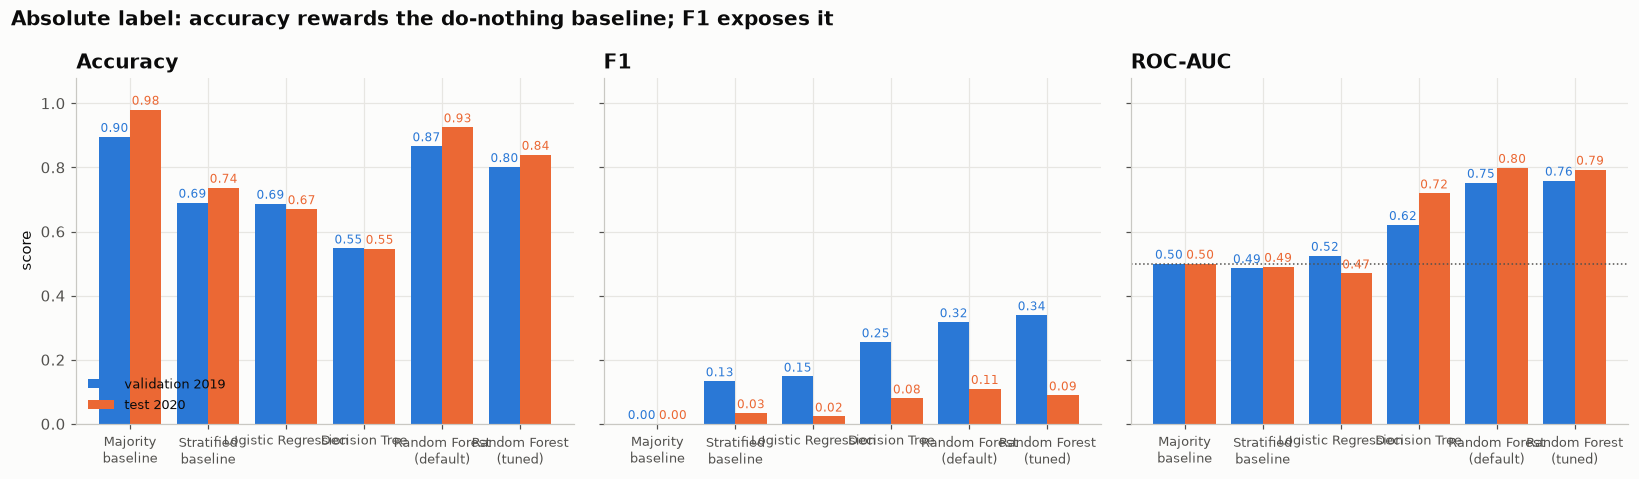

In [10]:
# ---- Figure 2: model comparison, validation vs test -------------------------------------------
def comparison_figure(val_df, test_df, title, fname, order):
    metrics = ["Accuracy", "F1", "ROC-AUC"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
    xs = np.arange(len(order))
    for ax, met in zip(axes, metrics):
        ax.bar(xs - 0.2, val_df.loc[order, met], 0.4, color=BLUE, label="validation 2019")
        ax.bar(xs + 0.2, test_df.loc[order, met], 0.4, color=ACCENT, label="test 2020")
        for i, (a, b) in enumerate(zip(val_df.loc[order, met], test_df.loc[order, met])):
            ax.text(i - 0.2, a + 0.015, f"{a:.2f}", ha="center", fontsize=8, color=BLUE)
            ax.text(i + 0.2, b + 0.015, f"{b:.2f}", ha="center", fontsize=8, color=ACCENT)
        ax.set_xticks(xs)
        ax.set_xticklabels([n.replace(" (", "\n(").replace(" baseline", "\nbaseline")
                            for n in order], fontsize=8.5)
        ax.set_ylim(0, 1.08)
        ax.set_title(met)
        if met == "ROC-AUC":
            ax.axhline(0.5, color=GRAY, lw=1, ls=":")
    axes[0].set_ylabel("score")
    axes[0].legend(fontsize=8.5, loc="lower left")
    fig.suptitle(title, x=0.005, ha="left", fontweight="bold", fontsize=13)
    fig.tight_layout()
    save(fig, fname)
    plt.show()


comparison_figure(val_abs, test_abs,
                  "Absolute label: accuracy rewards the do-nothing baseline; F1 exposes it",
                  "fig02_model_comparison_absolute", order)

**Figure 2.** The three panels tell three different stories about the same six models, which is the
point of showing them together.

**Accuracy** (left) ranks the *majority baseline* at or near the top in both years — 0.895 on
validation, 0.980 on test. Any reader who stops at this panel concludes the problem is nearly solved.

**F1** (middle) inverts the ranking: the baseline scores exactly 0, and the tuned Random Forest —
worst-but-one on test accuracy — is best. It also shows the real damage: F1 falls from 0.339 on
validation to 0.089 on test.

**ROC-AUC** (right) shows something neither of the others does. The tuned forest's AUC **rises** from
0.759 to 0.793 between validation and test. The model's ability to *order* ZIP codes did not degrade at
all; it improved slightly. Only its ability to convert that order into a yes/no decision collapsed.

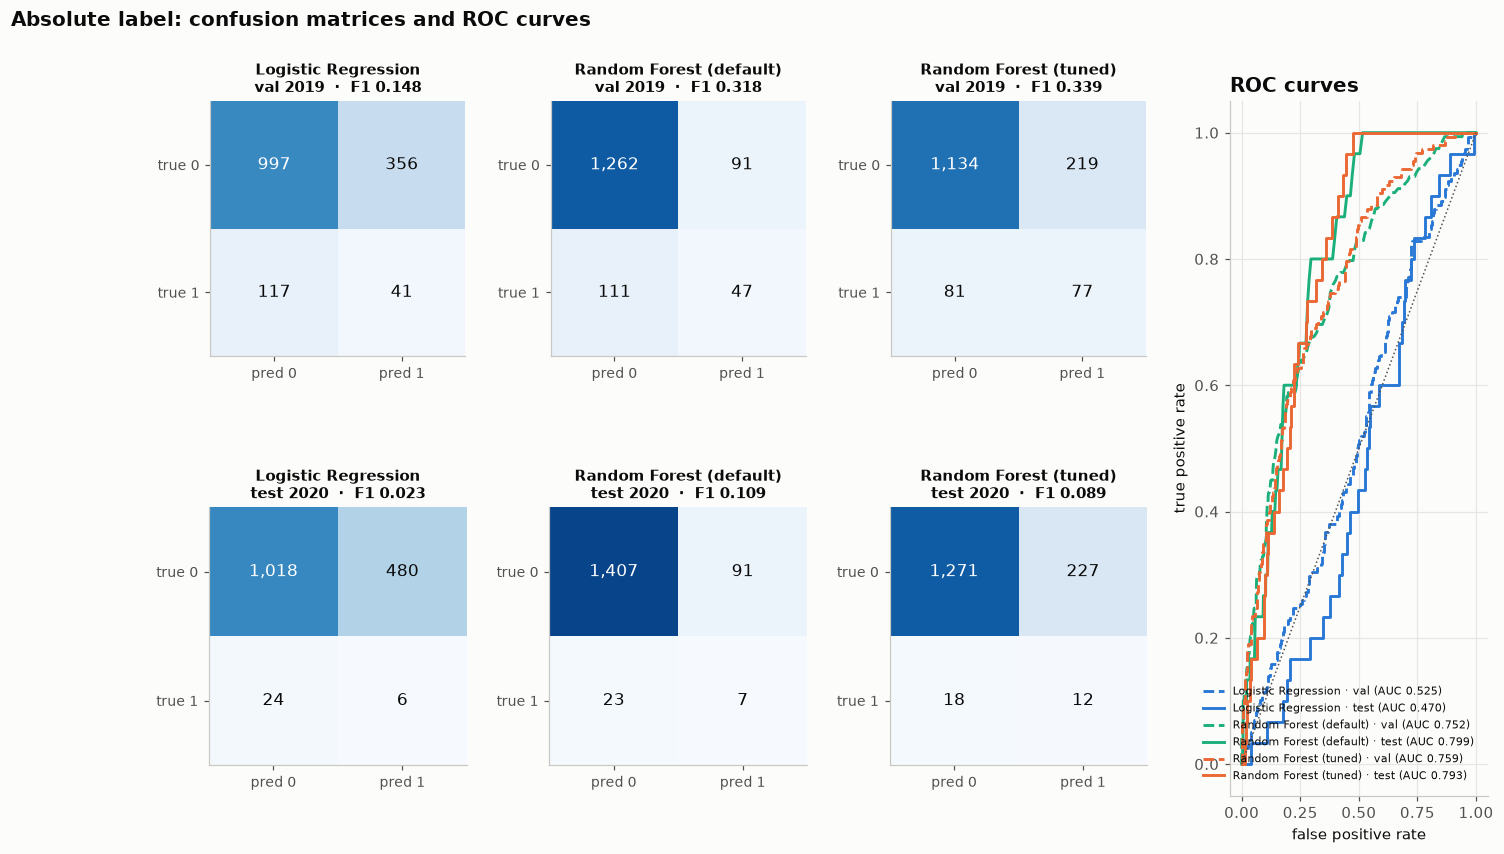

In [11]:
# ---- Figure 3: confusion matrices + ROC curves -------------------------------------------------
def confusion_roc_figure(fitted, X_va, y_va, X_te, y_te, names, title, fname):
    fig = plt.figure(figsize=(15, 8.2))
    gs_ = fig.add_gridspec(2, 4, height_ratios=[1, 1.25], hspace=0.42, wspace=0.32)

    for j, name in enumerate(names):
        for i, (X, y, tag) in enumerate([(X_va, y_va, "val 2019"), (X_te, y_te, "test 2020")]):
            ax = fig.add_subplot(gs_[i, j])
            cm = confusion_matrix(y, fitted[name].predict(X))
            ax.imshow(cm / cm.sum(), cmap="Blues", vmin=0, vmax=1)
            for r in range(2):
                for c in range(2):
                    ax.text(c, r, f"{cm[r, c]:,}", ha="center", va="center", fontsize=11,
                            color="white" if cm[r, c] / cm.sum() > 0.5 else "#0b0b0b")
            ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"], fontsize=9)
            ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"], fontsize=9)
            ax.grid(False)
            f1 = f1_score(y, fitted[name].predict(X), zero_division=0)
            ax.set_title(f"{name}\n{tag}  ·  F1 {f1:.3f}", fontsize=9.5, loc="center")

    ax = fig.add_subplot(gs_[:, 3])
    for name, c in zip(names, [BLUE, GREEN, ACCENT]):
        for (X, y, tag), ls in [((X_va, y_va, "val"), "--"), ((X_te, y_te, "test"), "-")]:
            fpr, tpr, _ = roc_curve(y, fitted[name].predict_proba(X)[:, 1])
            ax.plot(fpr, tpr, ls, color=c, lw=1.9,
                    label=f"{name} · {tag} (AUC {roc_auc_score(y, fitted[name].predict_proba(X)[:, 1]):.3f})")
    ax.plot([0, 1], [0, 1], color=GRAY, lw=1, ls=":")
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.set_title("ROC curves")
    ax.legend(fontsize=7.0, loc="lower right", borderaxespad=0.9)

    fig.suptitle(title, x=0.005, ha="left", fontweight="bold", fontsize=13)
    save(fig, fname)
    plt.show()


confusion_roc_figure(fitted_abs, X_va, y_va, X_te, y_te,
                     ["Logistic Regression", "Random Forest (default)", "Random Forest (tuned)"],
                     "Absolute label: confusion matrices and ROC curves",
                     "fig03_confusion_roc_absolute")

**Figure 3.** The tuned forest's 2020 confusion matrix is `[[1271, 227], [18, 12]]` — 227 false
positives against 12 true positives. Precision 0.050.

But look at what the same matrix says about *recall*: 12 of 30 true positives found, and the 227 false
alarms are drawn from 1,498 negatives — a 15% false-positive rate. The ROC curve built from those two
rates sits well above the diagonal. **The matrix is bad and the curve is good, from the same
predictions**, because the matrix depends on the threshold and the curve does not.

## 2.6 Diagnosis: the model's ranking survived; its calibration did not

Two properties of a probabilistic classifier come apart here:

- **Discrimination** — does it give higher scores to positives than negatives? Measured by ROC-AUC.
  **Prevalence-invariant.**
- **Calibration** — do its scores mean what they claim, so that a 0.5 cut lands in the right place?
  **Destroyed by a prevalence shift.**

The test below is direct: score every 2020 ZIP code, and instead of cutting at 0.5, take the **top 30**
— the number of positives that actually exist. If the ranking is sound, those 30 should be enriched in
true positives even though the 0.5 cut is not.

In [12]:
def ranking_report(model, X, y, tag):
    prob = model.predict_proba(X)[:, 1]
    n_pos = int(y.sum())
    top_idx = np.argsort(-prob)[:n_pos]
    hits = int(y.values[top_idx].sum())
    base = y.mean()
    dec = (pd.DataFrame({"decile": pd.qcut(pd.Series(prob).rank(method="first"), 10, labels=False),
                         "y": y.values}).groupby("decile")["y"].mean())
    return {
        "tag": tag, "prevalence": base,
        "mean predicted prob": prob.mean(),
        "ROC-AUC": roc_auc_score(y, prob),
        f"precision @ top-{n_pos}": hits / n_pos,
        "lift @ top-k": (hits / n_pos) / base,
        "top-decile hit rate": dec.iloc[-1],
        "top-decile lift": dec.iloc[-1] / base,
        "bottom-decile hit rate": dec.iloc[0],
    }, dec


rf_abs = fitted_abs["Random Forest (tuned)"]
rep_va, dec_va = ranking_report(rf_abs, X_va, y_va, "val 2019")
rep_te, dec_te = ranking_report(rf_abs, X_te, y_te, "test 2020")
print(pd.DataFrame([rep_va, rep_te]).set_index("tag").T.round(4).to_string())

tag                     val 2019  test 2020
prevalence                 0.105      0.020
mean predicted prob        0.344      0.311
ROC-AUC                    0.759      0.793
precision @ top-158        0.310        NaN
lift @ top-k               2.966      3.396
top-decile hit rate        0.318      0.052
top-decile lift            3.040      2.663
bottom-decile hit rate     0.007      0.000
precision @ top-30           NaN      0.067


> **The 2020 test year, tuned Random Forest.** Mean predicted probability **0.311** against an actual
> positive rate of **0.020** — the model expects a 2018-like world and meets a 2020 one. That is the
> calibration failure, quantified: it is off by a factor of **16**.
>
> And yet: **precision in the top 30 is 0.0667, a 3.40× lift over the base rate**; the **top decile
> contains 2.66× its share** of true positives, and the **bottom five deciles contain none at all** —
> 764 ZIP codes ranked lowest, zero high-growth outcomes among them.

Both statements are true simultaneously. The model has learned something real about which ZIP codes
outperform, and has learned nothing at all about how much California housing will appreciate — which is
precisely D2's conclusion, arrived at by a different route.

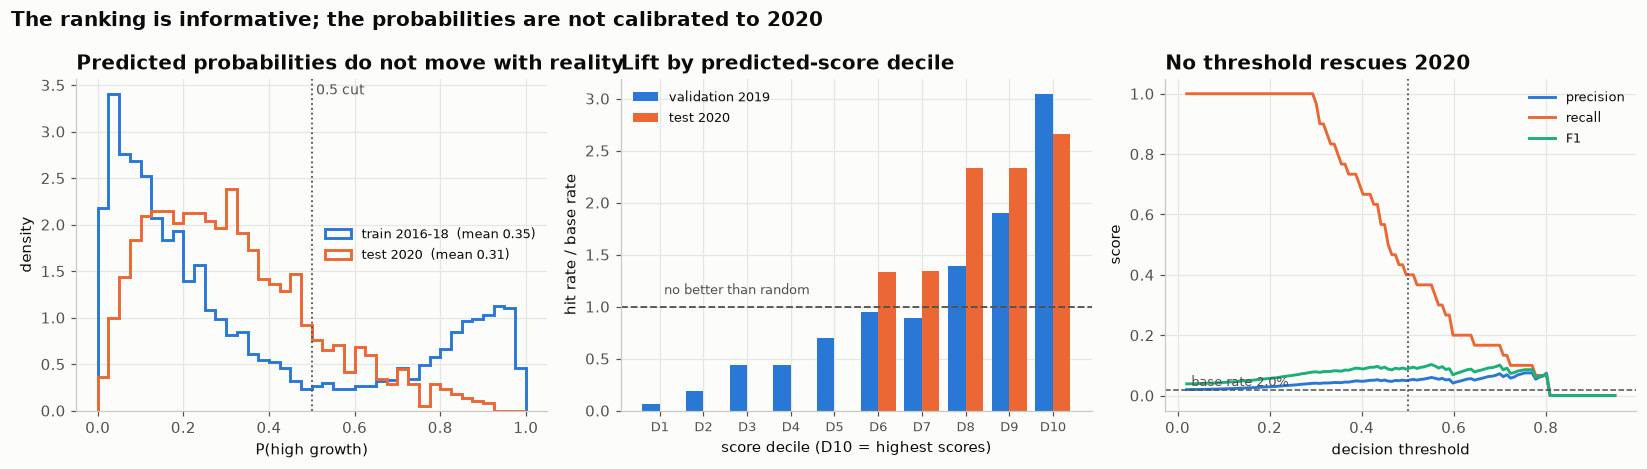

In [13]:
# ---- Figure 4: ranking survives, calibration does not ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

ax = axes[0]
for X, y, tag, c in [(X_tr, y_tr, "train 2016-18", BLUE), (X_te, y_te, "test 2020", ACCENT)]:
    ax.hist(rf_abs.predict_proba(X)[:, 1], bins=np.linspace(0, 1, 41), density=True,
            histtype="step", lw=1.9, color=c, label=f"{tag}  (mean {rf_abs.predict_proba(X)[:, 1].mean():.2f})")
ax.axvline(0.5, color=GRAY, lw=1.2, ls=":")
ax.text(0.51, 3.4, "0.5 cut", color=GRAY, fontsize=9)
ax.set_title("Predicted probabilities do not move with reality")
ax.set_xlabel("P(high growth)"); ax.set_ylabel("density")
ax.legend(fontsize=8.5)

ax = axes[1]
w = 0.4
xs = np.arange(10)
ax.bar(xs - 0.2, dec_va / y_va.mean(), w, color=BLUE, label="validation 2019")
ax.bar(xs + 0.2, dec_te / y_te.mean(), w, color=ACCENT, label="test 2020")
ax.axhline(1.0, color=GRAY, lw=1.2, ls="--")
ax.text(0.1, 1.12, "no better than random", color=GRAY, fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels([f"D{i+1}" for i in xs], fontsize=8.5)
ax.set_title("Lift by predicted-score decile")
ax.set_xlabel("score decile (D10 = highest scores)"); ax.set_ylabel("hit rate / base rate")
ax.legend(fontsize=8.5)

ax = axes[2]
prob_te = rf_abs.predict_proba(X_te)[:, 1]
ths = np.linspace(0.02, 0.95, 120)
prec = [precision_score(y_te, (prob_te >= t).astype(int), zero_division=0) for t in ths]
rec  = [recall_score(y_te, (prob_te >= t).astype(int)) for t in ths]
f1s  = [f1_score(y_te, (prob_te >= t).astype(int), zero_division=0) for t in ths]
ax.plot(ths, prec, color=BLUE, lw=1.9, label="precision")
ax.plot(ths, rec,  color=ACCENT, lw=1.9, label="recall")
ax.plot(ths, f1s,  color=GREEN, lw=1.9, label="F1")
ax.axvline(0.5, color=GRAY, lw=1.2, ls=":")
ax.axhline(y_te.mean(), color=GRAY, lw=1, ls="--")
ax.text(0.03, y_te.mean() + 0.012, "base rate 2.0%", color=GRAY, fontsize=8.5)
ax.set_title("No threshold rescues 2020")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.legend(fontsize=8.5)

fig.suptitle("The ranking is informative; the probabilities are not calibrated to 2020",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig04_ranking_vs_calibration")
plt.show()

**Figure 4.** The right panel closes off the obvious objection — *couldn't you just move the
threshold?* No. Sweeping the cut from 0.02 to 0.95 never lifts test F1 above ~0.13, because precision is
bounded by the 2.0% base rate at every cut. The problem is not a badly chosen threshold; it is that
**there is almost nothing left to find**. The class the model was trained to detect has nearly ceased
to exist in the test year.

The correct response is not to tune harder. It is to fix the label.

## 2.7 The repair: define "high growth" *within* each base year

D2 §9.8 predicted this and prescribed the fix. Instead of one fixed threshold, take the top quartile
**of each base year separately**:

```python
panel["high_growth_rel"] = panel.groupby("base_year")[TARGET].transform(
    lambda s: (s >= s.quantile(0.75)).astype(int))
```

**Does this leak?** It is worth being precise, because it looks like it might. The threshold for the
2020 test rows is computed from 2020 outcomes — but it uses **only the marginal distribution of the
outcome within that year**, never the pairing of outcome to ZIP code, and no feature is touched. What
it removes is the year's overall level, which is exactly the quantity D2 established that
cross-sectional features cannot predict and which no user of this model would need it to predict.

The question changes accordingly, and it changes into a more useful one:

> ~~"Will this ZIP code grow more than 58.7% over five years?"~~ — unanswerable without knowing the
> macro regime.
>
> **"Will this ZIP code finish in the top quarter of California ZIP codes for its period?"** — a
> relative question, stable at 25% in every year, and the question an investor comparing markets
> actually asks.

Everything below is re-run identically on this label: same features, same split, same grid, same folds.

In [14]:
Xr_tr, yr_tr, Xr_va, yr_va, Xr_te, yr_te, groups_r = get_splits("high_growth_rel")
print("positive rate by split -- fixed at 25% by construction:")
print(f"  train {yr_tr.mean():.4f} ({int(yr_tr.sum()):,})"
      f"   val {yr_va.mean():.4f} ({int(yr_va.sum()):,})"
      f"   test {yr_te.mean():.4f} ({int(yr_te.sum()):,})")

gs_rel = tune_rf(Xr_tr, yr_tr, groups_r, "within-year label")

models_rel = make_models(gs_rel.best_params_)
fitted_rel, res_rel = {}, {}
for name, m in models_rel.items():
    m.fit(Xr_tr, yr_tr)
    fitted_rel[name] = m
    res_rel[name] = {"val": scores(m, Xr_va, yr_va), "test": scores(m, Xr_te, yr_te)}

val_rel  = pd.DataFrame({n: res_rel[n]["val"]  for n in order}).T
test_rel = pd.DataFrame({n: res_rel[n]["test"] for n in order}).T
print(f"\nVALIDATION (2019)  --  positive rate {yr_va.mean():.4f}")
print(val_rel.round(4).to_string())
print(f"\nTEST (2020)  --  positive rate {yr_te.mean():.4f}")
print(test_rel.round(4).to_string())

positive rate by split -- fixed at 25% by construction:
  train 0.2500 (1,112)   val 0.2502 (378)   test 0.2500 (382)


[within-year label]  36 combinations x 3 folds = 108 fits
  best CV F1 : 0.5137
  best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}



VALIDATION (2019)  --  positive rate 0.2502
                         Accuracy  Precision  Recall    F1  ROC-AUC  Avg prec.  n flagged
Majority baseline           0.750      0.000   0.000 0.000    0.500      0.250      0.000
Stratified baseline         0.616      0.236   0.238 0.237    0.490      0.247    382.000
Logistic Regression         0.647      0.337   0.426 0.376    0.601      0.326    478.000
Decision Tree               0.694      0.380   0.357 0.368    0.638      0.355    355.000
Random Forest (default)     0.793      0.668   0.341 0.452    0.792      0.572    193.000
Random Forest (tuned)       0.735      0.478   0.661 0.555    0.780      0.545    523.000

TEST (2020)  --  positive rate 0.2500
                         Accuracy  Precision  Recall    F1  ROC-AUC  Avg prec.  n flagged
Majority baseline           0.750      0.000   0.000 0.000    0.500      0.250      0.000
Stratified baseline         0.610      0.223   0.225 0.224    0.482      0.244    386.000
Logistic Regress

### The comparison that justifies the repair

| | absolute label | within-year label |
|---|---|---|
| Test positive rate | **0.0196** | 0.2500 |
| Best CV F1 (grid) | 0.4658 | **0.5137** |
| Tuned RF — **test F1** | **0.089** | **0.406** |
| Tuned RF — test precision | 0.050 | 0.491 |
| Tuned RF — test ROC-AUC | 0.793 | 0.719 |
| Logistic Regression — test F1 | 0.023 | **0.440** |
| Majority baseline — test accuracy | **0.980** | 0.750 |

**Test F1 rises 4.6× for the tuned forest and 19× for logistic regression**, on the same features, the
same rows and the same folds. Only the question changed.

Two honest caveats, both visible in the table:

1. **Test ROC-AUC *fell* slightly, 0.793 → 0.719.** The relative label is in one sense a *harder*
   ranking problem: the absolute label's positives in 2020 were the extreme tail of the distribution
   (the 30 fastest-growing ZIPs statewide), which are easier to separate than the boundary between the
   73rd and 77th percentile. The gain is in usability, not in raw discrimination.
2. **F1 still drops from validation to test** (0.555 → 0.406), and precision at 0.491 means **half the
   ZIP codes the model flags are wrong**. Fixing the label removed the level shift; it did not make
   five-year housing outcomes easy to predict. The residual gap is genuine year-to-year variation in
   *which kind* of ZIP outperforms — 2020's winners were not 2017's winners.

The tuned forest at CV F1 0.5137 chose **`max_depth=10`** this time rather than `None`, with
`class_weight="balanced"` again decisive. With a balanced 25%-in-every-year label the deepest trees
begin to overfit where they did not before — the shape the plan originally anticipated, now visible
because the prevalence artifact has been removed.

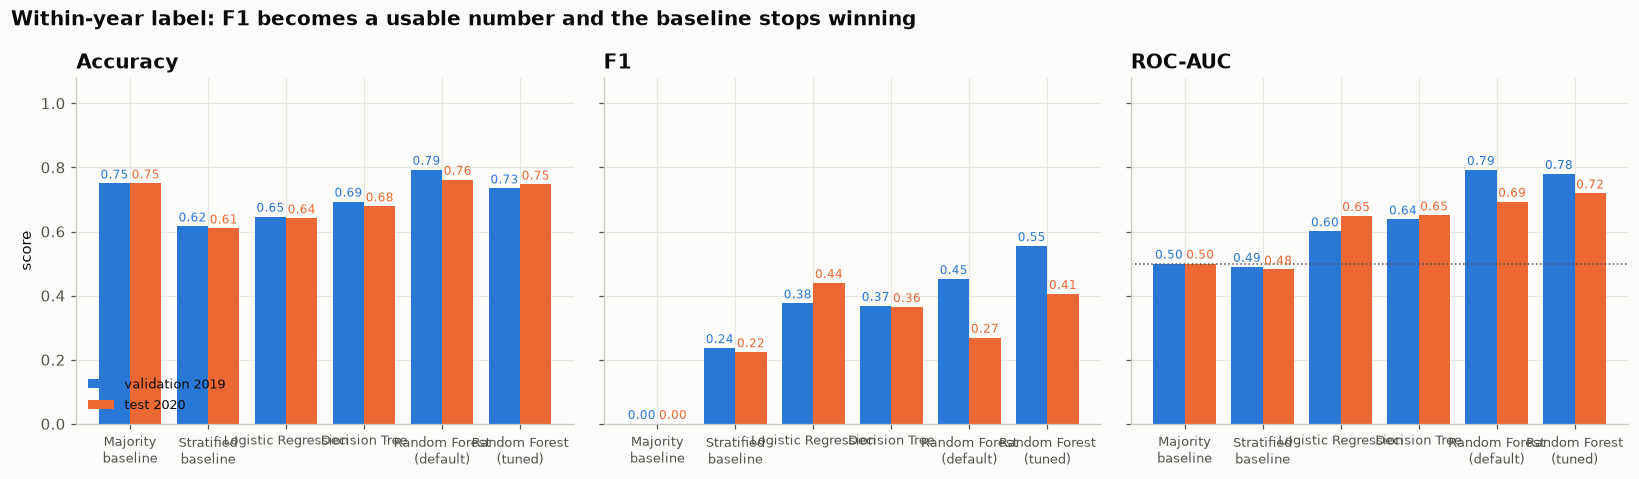

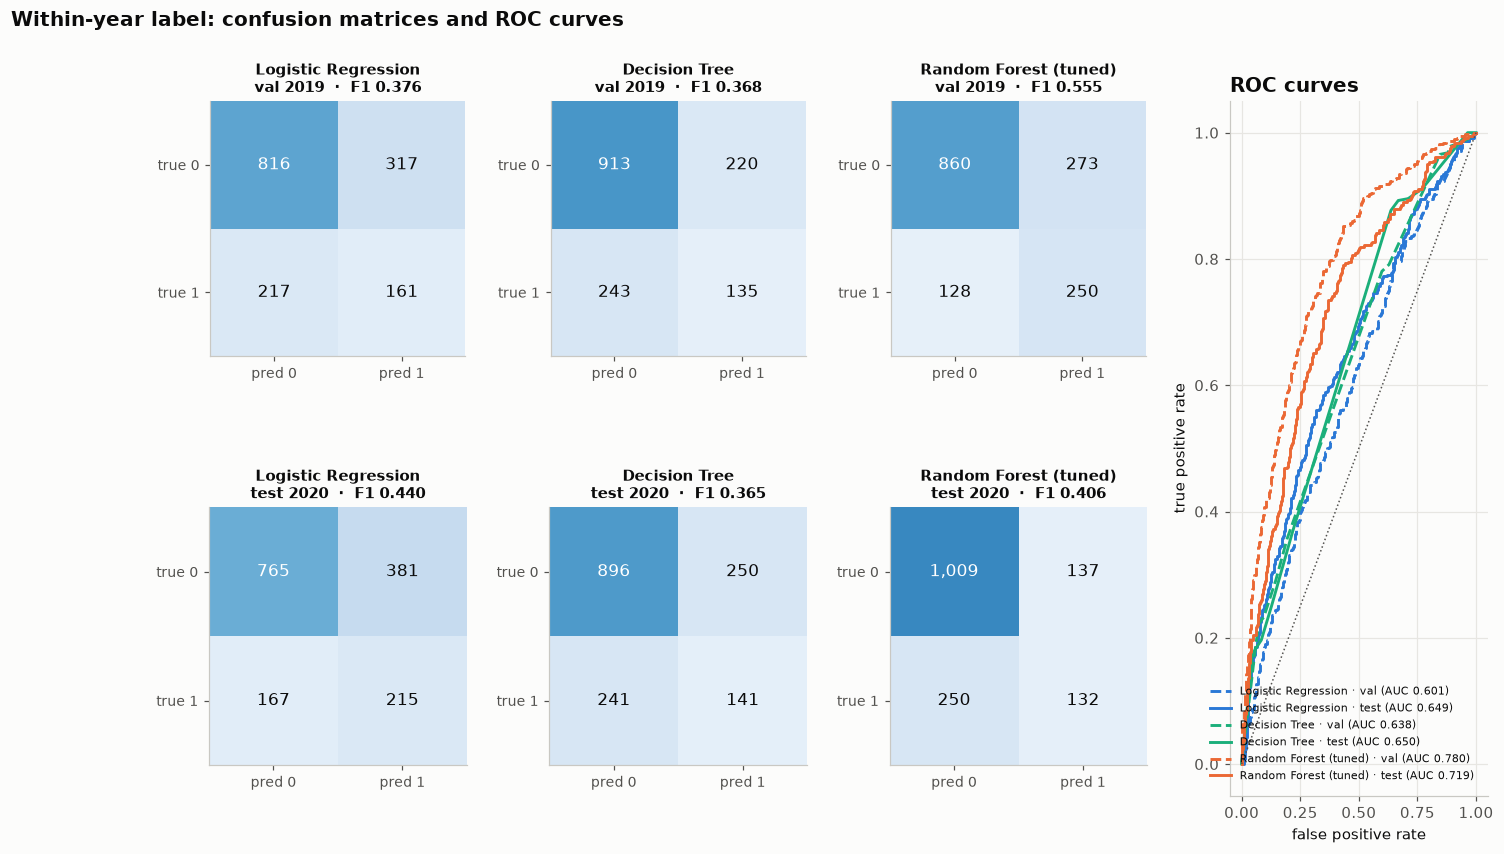

In [15]:
comparison_figure(val_rel, test_rel,
                  "Within-year label: F1 becomes a usable number and the baseline stops winning",
                  "fig05_model_comparison_relative", order)

confusion_roc_figure(fitted_rel, Xr_va, yr_va, Xr_te, yr_te,
                     ["Logistic Regression", "Decision Tree", "Random Forest (tuned)"],
                     "Within-year label: confusion matrices and ROC curves",
                     "fig06_confusion_roc_relative")

**Figures 5–6.** The confusion matrices are now readable as decisions. The tuned forest's 2020 matrix is
`[[1009, 137], [250, 132]]`: of 269 ZIP codes flagged, 132 really were top-quartile (precision 0.491,
just under 2× the 25% base rate), at the cost of missing 250. Logistic regression trades the other way
— recall 0.563, precision 0.361 — and posts the higher test F1 of the two (0.440 vs 0.406) despite the
lower AUC, because its errors are distributed more usefully at this base rate.

The ranking check tells the same story in one number: **the top decile of 2020 predictions is 53.6%
true positives against a 25% base rate (2.14× lift); the bottom decile is 7.8% (0.31×).**

In [16]:
rf_rel = fitted_rel["Random Forest (tuned)"]
rep_va_r, dec_va_r = ranking_report(rf_rel, Xr_va, yr_va, "val 2019")
rep_te_r, dec_te_r = ranking_report(rf_rel, Xr_te, yr_te, "test 2020")
print(pd.DataFrame([rep_va_r, rep_te_r]).set_index("tag").T.round(4).to_string())

tag                     val 2019  test 2020
prevalence                 0.250      0.250
mean predicted prob        0.426      0.365
ROC-AUC                    0.780      0.719
precision @ top-378        0.521        NaN
lift @ top-k               2.083      1.853
top-decile hit rate        0.662      0.536
top-decile lift            2.647      2.144
bottom-decile hit rate     0.040      0.078
precision @ top-382          NaN      0.463


## 2.8 What the classifiers learned

Two independent views: signed standardized coefficients from logistic regression (direction and
magnitude, on a common scale because the scaler standardized every feature), and Gini importances from
the tuned forest (magnitude only, no direction).

In [17]:
lr_rel = fitted_rel["Logistic Regression"]
coefs = pd.Series(lr_rel.named_steps["model"].coef_[0], index=FEATURES).sort_values()
odds = np.exp(coefs)
imps = pd.Series(rf_rel.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("Logistic Regression -- standardized coefficients and odds ratios per +1 SD")
print(pd.DataFrame({"coefficient": coefs, "odds ratio": odds}).round(3).to_string())
print("\nTuned Random Forest -- Gini importance")
print(imps.round(4).to_string())

Logistic Regression -- standardized coefficients and odds ratios per +1 SD
                           coefficient  odds ratio
price_to_rent_ratio             -1.574       0.207
median_household_income         -0.669       0.512
median_gross_rent               -0.350       0.705
home_value_3yr_growth_pct       -0.332       0.718
price_to_income_ratio           -0.314       0.731
bachelor_degree_pct             -0.106       0.900
population_growth_pct            0.006       1.006
home_value_1yr_growth_pct        0.108       1.114
population                       0.212       1.237
unemployment_rate                0.249       1.283
current_home_value               1.851       6.366

Tuned Random Forest -- Gini importance
home_value_3yr_growth_pct   0.131
bachelor_degree_pct         0.131
price_to_rent_ratio         0.112
current_home_value          0.105
unemployment_rate           0.085
home_value_1yr_growth_pct   0.084
population                  0.084
median_household_income     0.074
m

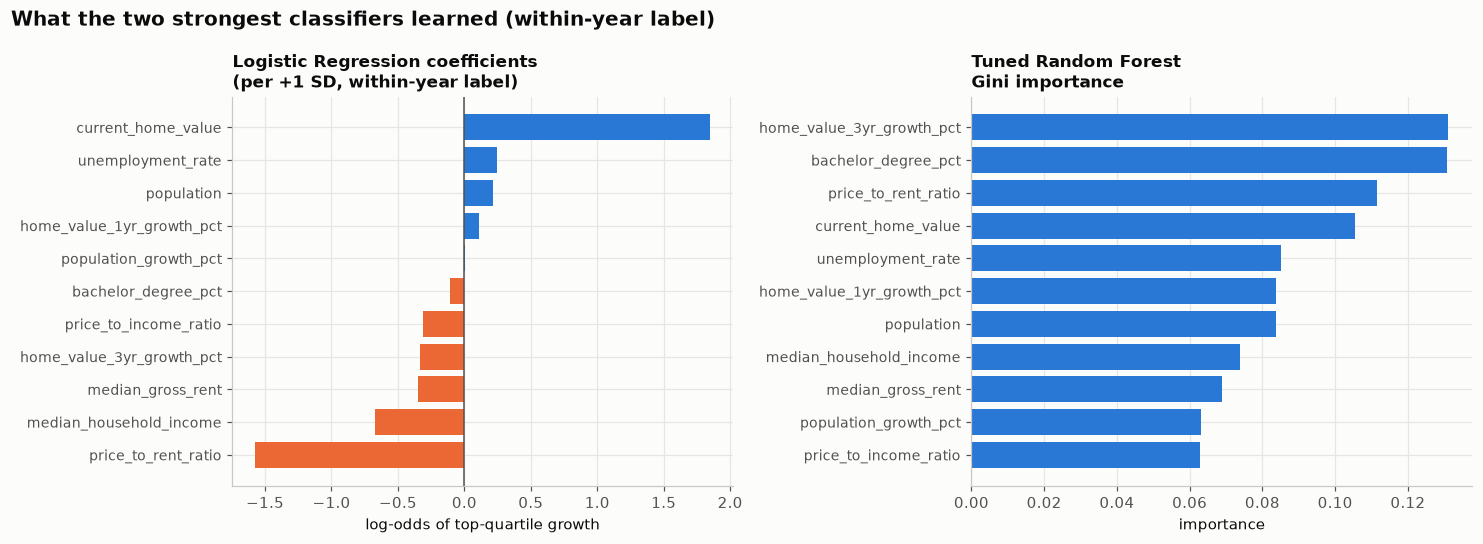

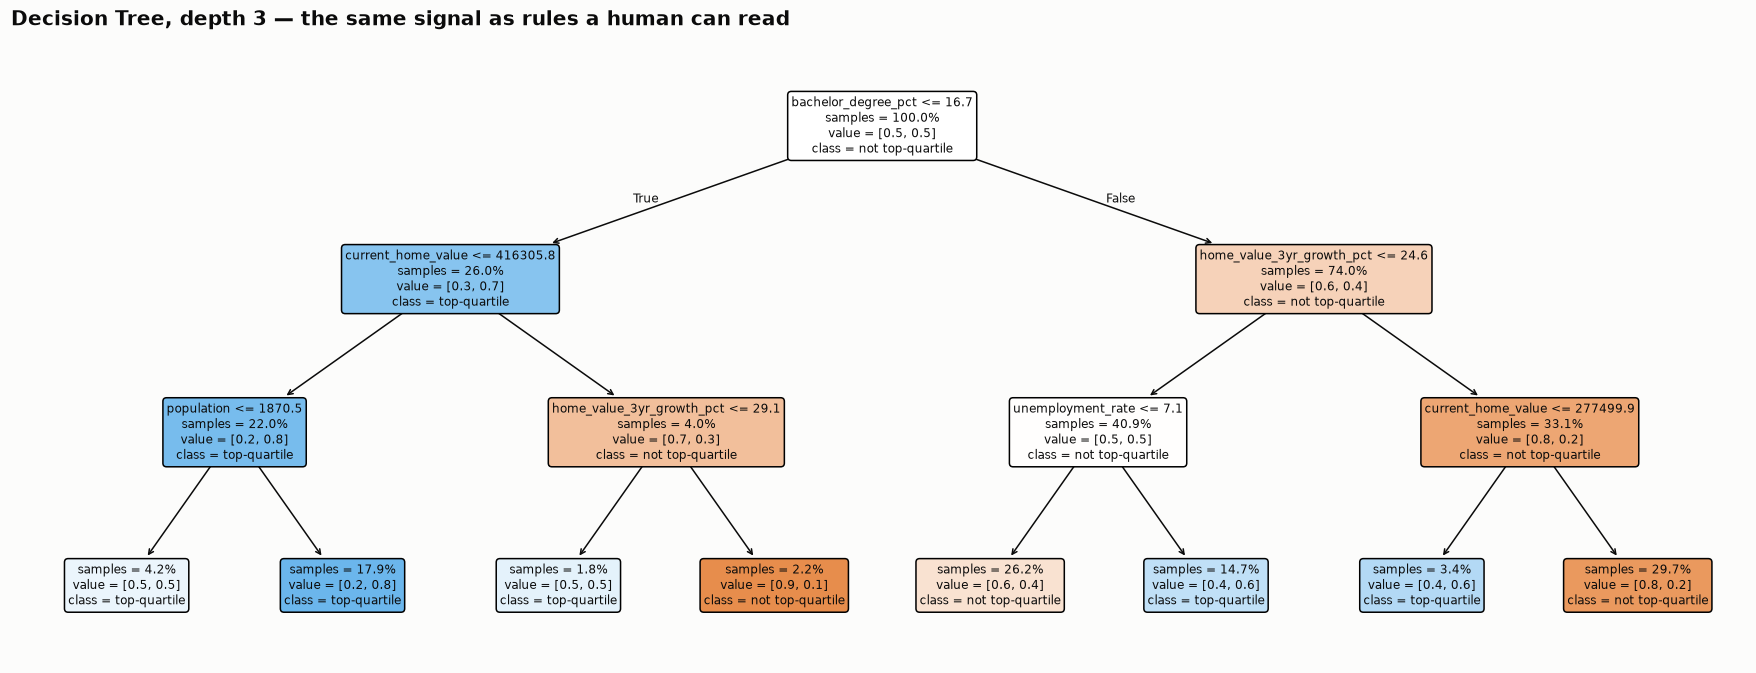

|--- bachelor_degree_pct <= 16.7
|   |--- current_home_value <= 416305.8
|   |   |--- population <= 1870.5
|   |   |   |--- class: 1
|   |   |--- population >  1870.5
|   |   |   |--- class: 1
|   |--- current_home_value >  416305.8
|   |   |--- home_value_3yr_growth_pct <= 29.1
|   |   |   |--- class: 1
|   |   |--- home_value_3yr_growth_pct >  29.1
|   |   |   |--- class: 0
|--- bachelor_degree_pct >  16.7
|   |--- home_value_3yr_growth_pct <= 24.6
|   |   |--- unemployment_rate <= 7.1
|   |   |   |--- class: 0
|   |   |--- unemployment_rate >  7.1
|   |   |   |--- class: 1
|   |--- home_value_3yr_growth_pct >  24.6
|   |   |--- current_home_value <= 277499.9
|   |   |   |--- class: 1
|   |   |--- current_home_value >  277499.9
|   |   |   |--- class: 0

depth-3 tree: val F1 0.335  test F1 0.327  test AUC 0.596


In [18]:
# ---- Figure 7: what the classifiers learned ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

ax = axes[0]
cols = [ACCENT if v < 0 else BLUE for v in coefs]
ax.barh(range(len(coefs)), coefs.values, color=cols)
ax.set_yticks(range(len(coefs))); ax.set_yticklabels(coefs.index, fontsize=9)
ax.axvline(0, color=GRAY, lw=1)
ax.set_title("Logistic Regression coefficients\n(per +1 SD, within-year label)", fontsize=11)
ax.set_xlabel("log-odds of top-quartile growth")

ax = axes[1]
ax.barh(range(len(imps)), imps.values[::-1], color=BLUE)
ax.set_yticks(range(len(imps))); ax.set_yticklabels(imps.index[::-1], fontsize=9)
ax.set_title("Tuned Random Forest\nGini importance", fontsize=11)
ax.set_xlabel("importance")

fig.suptitle("What the two strongest classifiers learned (within-year label)",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig07_feature_importance")
plt.show()

# ---- Figure 8: the depth-3 tree, on its own so the boxes are legible ---------------------------
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, class_weight="balanced",
                            random_state=RANDOM_STATE).fit(Xr_tr, yr_tr)

fig, ax = plt.subplots(figsize=(16, 6.2))
plot_tree(dt, feature_names=FEATURES, class_names=["not top-quartile", "top-quartile"],
          filled=True, impurity=False, proportion=True, fontsize=8, ax=ax,
          precision=1, rounded=True)
ax.grid(False)
fig.suptitle("Decision Tree, depth 3 — the same signal as rules a human can read",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig08_decision_tree")
plt.show()

print(export_text(dt, feature_names=FEATURES, decimals=1))
print(f"depth-3 tree: val F1 {f1_score(yr_va, dt.predict(Xr_va)):.3f}"
      f"  test F1 {f1_score(yr_te, dt.predict(Xr_te)):.3f}"
      f"  test AUC {roc_auc_score(yr_te, dt.predict_proba(Xr_te)[:, 1]):.3f}")

**Figures 7–8 — and one coefficient that must not be read at face value.**

**Logistic regression.** The largest negative coefficient is **`price_to_rent_ratio` at −1.574**: a
one-standard-deviation increase in price-to-rent multiplies the odds of finishing top-quartile by
**0.21**, a nearly five-fold reduction. `median_household_income` (−0.669), `median_gross_rent`
(−0.350) and `price_to_income_ratio` (−0.314) follow, all negative. On the positive side,
`unemployment_rate` (+0.249) and `population` (+0.212). **This is D2's affordability finding restated
in classification form**: expensive-relative-to-fundamentals markets underperform, and cheaper ones
with weaker labour markets outperform.

**The exception is `current_home_value` at +1.851 (odds ratio 6.37), the largest coefficient in the
model — and it is a collinearity artifact, not a finding.** Its raw correlation with growth is
negative; it turns strongly positive only *conditional on* the affordability ratios, which have
`current_home_value` in their numerator. The model is reading it as "expensive **for its
price-to-rent ratio**," which is a statement about the denominator (rent), not about price. D2 hit the
same instability and responded with grouped permutation importance over correlated blocks. **Any single
coefficient in a collinear model describes a partial derivative, not a market.**

**Random Forest.** A flatter ranking, as tree importances usually are:
`home_value_3yr_growth_pct` (0.131), `bachelor_degree_pct` (0.131), `price_to_rent_ratio` (0.112),
`current_home_value` (0.105). Note that the forest ranks medium-run **momentum** first while logistic
regression ranks it 4th-from-negative — the forest is picking up a nonlinear relationship (moderate
prior growth good, extreme prior growth bad) that a linear model cannot represent with one sign.

**Decision Tree (Figure 8).** The depth-3 tree is the most legible artifact here and the weakest predictor (test
F1 0.327, AUC 0.596 — barely above chance). Its first split is `bachelor_degree_pct ≤ 16.7`, and its
left branch — low education, home value under $416k — is almost entirely labelled top-quartile. In
plain language: **the tree's first move is to find the cheap, less-educated ZIP codes, and it bets on
them.** The right branch splits on `home_value_3yr_growth_pct ≤ 24.6` and then on unemployment,
predicting top-quartile only for higher-unemployment ZIPs. It is included because it makes the
mechanism visible, not because it is competitive.

---
# 3. Clustering — what types of housing market does California contain?

## 3.1 The purpose is different

Classification and clustering are not two attempts at the same task. Classification is supervised: it
was handed the answer and asked to find a rule. Clustering is **unsupervised segmentation** — it is
handed only the market's *character* and asked what natural groups exist. The outcome is then brought
back in **afterwards, as a check, never as an input**.

Clustering on the target would be circular: groups defined by growth would trivially differ in growth.
The feature set is therefore the seven variables that describe what a market *is*:

```
current_home_value, median_gross_rent, median_household_income,
price_to_income_ratio, unemployment_rate, population_growth_pct, bachelor_degree_pct
```

## 3.2 Three preparation decisions

**(a) The 2020 slice only — 1,528 rows, one row per ZIP code.** Clustering the full 7,487-row panel
would put five near-identical copies of every ZIP into the space. K-Means minimizes within-cluster
squared distance and has no concept of a repeated unit, so those copies would inflate the apparent
density of common market types and distort every centroid. One ZIP, one point. 2020 is chosen as the
most recent and best-covered snapshot.

**(b) `StandardScaler` — mandatory.** `current_home_value` runs to ~10⁶ and `unemployment_rate` to
~10¹. Euclidean distance on raw features is essentially distance in dollars; every other variable would
be rounding error. Without scaling, K-Means here would be a slow way to sort ZIP codes by price.

**(c) Winsorize at the 1st/99th percentile.** A handful of ZIPs report `population_growth_pct` above
+500% — 96105 (Sierra County, population 351) at **+646.8%**, 92060 (Palomar Mountain, population 457)
at **+572.1%**. These are tiny ZCTAs whose Census tabulation boundaries changed mid-panel (D1 §6,
limitation 5), not housing markets that sextupled. Under squared-distance clustering a single such
point **captures an entire cluster for itself**: running K-Means unclipped at k=4 produces a cluster of
**two ZIP codes** with a mean population growth of 609%, wasting a quarter of the model on an artifact.
Clipping affects at most 32 of 1,528 values per feature and removes the pathology.

In [19]:
CLUSTER_FEATURES = [
    "current_home_value", "median_gross_rent", "median_household_income",
    "price_to_income_ratio", "unemployment_rate", "population_growth_pct", "bachelor_degree_pct",
]
assert TARGET not in CLUSTER_FEATURES, "clustering on the outcome would be circular"

snap = panel[panel.base_year == TEST_YEAR].copy()
print(f"2020 slice: {len(snap):,} ZIP codes, one row each "
      f"(duplicate zip_codes: {snap.zip_code.duplicated().sum()})")

print("\nwhy winsorizing is needed -- population_growth_pct extremes:")
print(snap.nlargest(4, "population_growth_pct")[
    ["zip_code", "city", "county", "population", "population_growth_pct"]].to_string(index=False))

lo_q, hi_q = snap[CLUSTER_FEATURES].quantile(0.01), snap[CLUSTER_FEATURES].quantile(0.99)
Cw = snap[CLUSTER_FEATURES].clip(lo_q, hi_q, axis=1)
print(f"\nvalues clipped per feature (of {len(snap):,}): "
      f"{(snap[CLUSTER_FEATURES] != Cw).sum().to_dict()}")

scaler_c = StandardScaler().fit(Cw)
Xc = scaler_c.transform(Cw)
print(f"\nscaled matrix {Xc.shape}   column means ~{np.abs(Xc.mean(0)).max():.1e}"
      f"   column sds ~{Xc.std(0).mean():.3f}")

2020 slice: 1,528 ZIP codes, one row each (duplicate zip_codes: 0)

why winsorizing is needed -- population_growth_pct extremes:
zip_code             city           county  population  population_growth_pct
   96105              NaN    Sierra County     351.000                646.809
   92060 Palomar Mountain San Diego County     457.000                572.059
   96126      Sierraville    Sierra County     166.000                201.818
   91934          Jacumba San Diego County     785.000                194.007

values clipped per feature (of 1,528): {'current_home_value': 32, 'median_gross_rent': 32, 'median_household_income': 32, 'price_to_income_ratio': 32, 'unemployment_rate': 16, 'population_growth_pct': 32, 'bachelor_degree_pct': 32}

scaled matrix (1528, 7)   column means ~3.3e-16   column sds ~1.000


## 3.3 Choosing *k* — elbow and silhouette, and what to do when they disagree

- **Elbow (inertia).** Within-cluster sum of squares always falls as *k* rises; the "elbow" is where it
  stops falling *fast*. Reported below as the percentage drop from *k*−1 to *k*.
- **Silhouette.** For each point, (nearest-other-cluster distance − own-cluster distance) / max of the
  two, averaged. Ranges −1 to +1; higher means tighter and better separated.
- Two extra diagnostics are added because the first two turn out not to settle it: **Calinski–Harabasz**
  and **Davies–Bouldin** (lower is better), plus a **stability check** — mean Adjusted Rand Index
  between the `random_state=42` solution and four other seeds. A partition that reshuffles when the
  seed changes is not a finding.

In [20]:
rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc)
    ari = np.mean([adjusted_rand_score(km.labels_,
                   KMeans(n_clusters=k, random_state=s, n_init=10).fit(Xc).labels_)
                   for s in [0, 1, 7, 2024]])
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Xc, km.labels_),
                 "Calinski-Harabasz": calinski_harabasz_score(Xc, km.labels_),
                 "Davies-Bouldin": davies_bouldin_score(Xc, km.labels_),
                 "smallest cluster": pd.Series(km.labels_).value_counts().min(),
                 "stability (ARI)": ari})
kdiag = pd.DataFrame(rows).set_index("k")
kdiag["inertia drop %"] = -kdiag["inertia"].pct_change() * 100
print(kdiag.round(4).to_string())

     inertia  silhouette  Calinski-Harabasz  Davies-Bouldin  smallest cluster  stability (ARI)  inertia drop %
k                                                                                                             
2  6,987.343       0.336            809.952           1.177               532            1.000             NaN
3  5,898.062       0.228            620.285           1.400               305            0.996          15.589
4  5,223.207       0.227            532.274           1.375               143            0.944          11.442
5  4,632.876       0.228            498.294           1.282               120            0.888          11.302
6  4,184.125       0.227            473.752           1.216                52            0.921           9.686
7  3,857.636       0.252            449.375           1.195                51            0.909           7.803
8  3,558.312       0.213            435.571           1.227                46            0.818           7.759
9

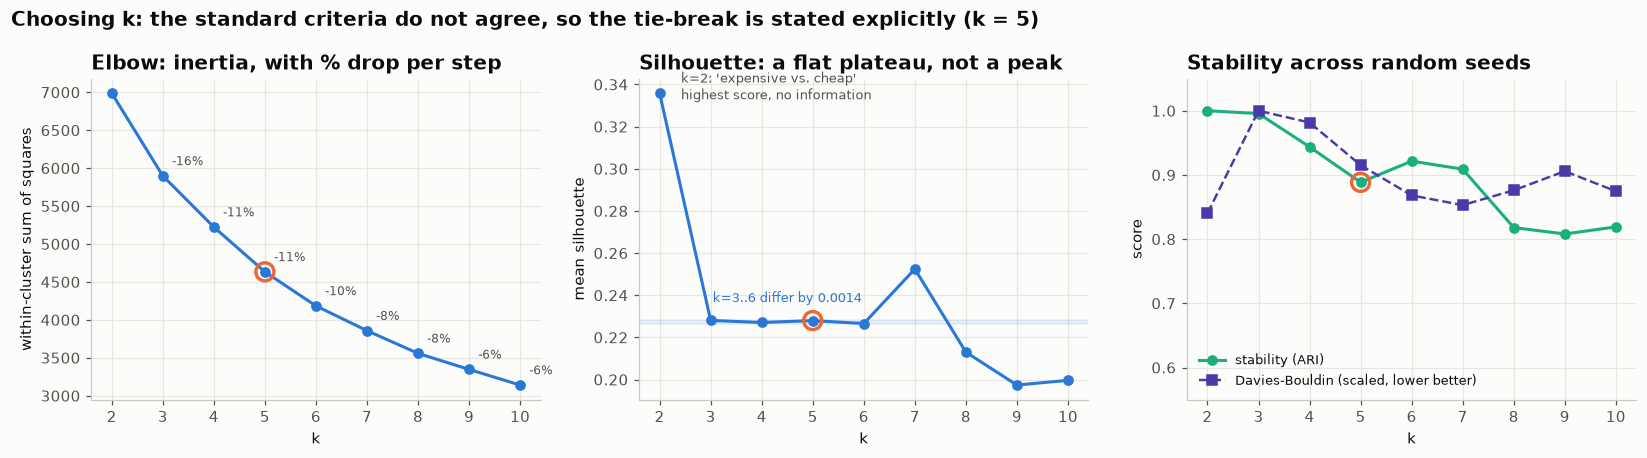

In [21]:
# ---- Figure 9: elbow and silhouette ------------------------------------------------------------
K_CHOSEN = 5
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ks = kdiag.index

ax = axes[0]
ax.plot(ks, kdiag["inertia"], marker="o", color=BLUE, lw=2)
ax.scatter([K_CHOSEN], [kdiag.loc[K_CHOSEN, "inertia"]], s=140, facecolor="none",
           edgecolor=ACCENT, lw=2.2, zorder=5)
for k in ks[1:]:
    ax.annotate(f"-{kdiag.loc[k, 'inertia drop %']:.0f}%", (k, kdiag.loc[k, "inertia"]),
                textcoords="offset points", xytext=(6, 7), fontsize=8, color=GRAY)
ax.set_title("Elbow: inertia, with % drop per step")
ax.set_xlabel("k"); ax.set_ylabel("within-cluster sum of squares")

ax = axes[1]
ax.plot(ks, kdiag["silhouette"], marker="o", color=BLUE, lw=2)
ax.scatter([K_CHOSEN], [kdiag.loc[K_CHOSEN, "silhouette"]], s=140, facecolor="none",
           edgecolor=ACCENT, lw=2.2, zorder=5)
ax.axhspan(kdiag.loc[3:6, "silhouette"].min(), kdiag.loc[3:6, "silhouette"].max(),
           color=BLUE, alpha=0.10)
ax.annotate("k=2: 'expensive vs. cheap'\nhighest score, no information",
            (2, kdiag.loc[2, "silhouette"]), textcoords="offset points", xytext=(14, -4),
            fontsize=8.5, color=GRAY)
ax.annotate("k=3..6 differ by 0.0014", (4.5, kdiag.loc[3:6, "silhouette"].max()),
            textcoords="offset points", xytext=(0, 12), fontsize=8.5, color=BLUE, ha="center")
ax.set_title("Silhouette: a flat plateau, not a peak")
ax.set_xlabel("k"); ax.set_ylabel("mean silhouette")

ax = axes[2]
ax.plot(ks, kdiag["stability (ARI)"], marker="o", color=GREEN, lw=2, label="stability (ARI)")
ax.plot(ks, kdiag["Davies-Bouldin"] / kdiag["Davies-Bouldin"].max(), marker="s", color=PURPLE,
        lw=1.6, ls="--", label="Davies-Bouldin (scaled, lower better)")
ax.scatter([K_CHOSEN], [kdiag.loc[K_CHOSEN, "stability (ARI)"]], s=140, facecolor="none",
           edgecolor=ACCENT, lw=2.2, zorder=5)
ax.set_ylim(0.55, 1.05)
ax.set_title("Stability across random seeds")
ax.set_xlabel("k"); ax.set_ylabel("score")
ax.legend(fontsize=8.5, loc="lower left")

fig.suptitle(f"Choosing k: the standard criteria do not agree, so the tie-break is stated explicitly "
             f"(k = {K_CHOSEN})", x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig09_elbow_silhouette")
plt.show()

### The choice, and an honest account of how it was made

**The elbow and the silhouette disagree, and the plan's tie-break rule ("prefer silhouette") does not
resolve it.** Here is what each actually says:

- **Elbow → k ≈ 3.** Inertia drops 15.6% going to k=3, then 11.4%, 11.3%, 9.7%, 7.8%. The bend is at 3,
  and it is a gentle one.
- **Silhouette → k = 2**, at **0.336**, the global maximum. But k=2 splits California into "expensive"
  and "cheap" and is useless as a segmentation. Beyond it, silhouette is **flat**: k=3 gives 0.2280,
  k=4 gives 0.2271, k=5 gives 0.2280, k=6 gives 0.2266 — a spread of **0.0014** across four different
  answers. There is a small local bump at k=7 (0.2524).

**The silhouette values themselves are the more important finding, and they are low.** A mean
silhouette of 0.23 means the clusters overlap substantially. **California ZIP codes do not fall into
discrete market types; they lie on a continuum**, and any partition is a useful summary of that
continuum rather than a discovery of hidden groups. That is stated here rather than buried, because
every interpretation below inherits it.

Since silhouette cannot discriminate among k=3…6, the tie-break must be substantive, and the criterion
used is stated **before** looking at the outcome:

> **Choose the smallest *k* at which the clusters are distinguished by *different features*, rather
> than by a single affluence gradient.**

At k=3 the three centroids are a **ladder**: every feature increases together from cluster to cluster.
The partition is a one-dimensional split of PC1 and adds nothing beyond "poor / middle / rich."
At **k=5** two clusters break that ladder — one with high home values but *below-average* income
(z = +0.86 value, −0.39 income), and one with sharply elevated unemployment (z = +1.59). Those are
distinct market *types*, not points on an affluence scale.

Stability supports it: **ARI 0.888 across five random seeds**, meaning the partition is essentially the
same solution regardless of initialisation.

**The disclosure that belongs with this choice:** k=5 also turns out to separate the growth outcome far
more sharply than k=3 or k=4 (§3.5). That was checked *after* the choice was made, and it is reported
as a result, not as the reason. A reader who prefers k=3 on the elbow can find its profile in the
diagnostic table above; the substantive conclusion — affordability separates growth — appears at every
*k*, only less sharply.

In [22]:
km = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10).fit(Xc)
snap["cluster"] = km.labels_

profile = snap.groupby("cluster")[CLUSTER_FEATURES].mean()
profile.insert(0, "n", snap["cluster"].value_counts().sort_index())
profile["mean 5yr growth"] = snap.groupby("cluster")[TARGET].mean()
profile["median 5yr growth"] = snap.groupby("cluster")[TARGET].median()
print("Cluster profile -- raw feature means (2020 slice)")
print(profile.round(2).to_string())

centers = pd.DataFrame(km.cluster_centers_, columns=CLUSTER_FEATURES)
print("\nCluster centroids in standardized units (z-scores) -- this is what K-Means actually saw")
print(centers.round(2).to_string())

Cluster profile -- raw feature means (2020 slice)
           n  current_home_value  median_gross_rent  median_household_income  price_to_income_ratio  unemployment_rate  population_growth_pct  bachelor_degree_pct  mean 5yr growth  median 5yr growth
cluster                                                                                                                                                                                               
0        659         471,638.690          1,360.060               67,991.880                  7.090              5.410                 -0.100               23.590           23.320             25.450
1        120       1,947,252.370          2,621.380              161,442.300                 12.220              3.960                  3.140               71.050           26.660             24.430
2        366         856,171.220          2,009.470              108,297.550                  8.070              4.770                  7.160             

## 3.4 Naming the clusters

"Cluster 0, Cluster 1, Cluster 2" is not a result. Each cluster is named from its own profile, using
identifying rules rather than hard-coded label numbers, so the names survive any change in K-Means'
arbitrary numbering.

In [23]:
# Identify each cluster by its defining trait, so names never depend on K-Means' label numbering.
p = profile[CLUSTER_FEATURES]
id_elite     = p["current_home_value"].idxmax()
id_stretched = p["price_to_income_ratio"].idxmax()
id_working   = p["unemployment_rate"].idxmax()
rest = [c for c in p.index if c not in {id_elite, id_stretched, id_working}]
id_affluent  = p.loc[rest, "bachelor_degree_pct"].idxmax()
id_midmarket = [c for c in rest if c != id_affluent][0]

NAMES = {
    id_elite:     "Elite Coastal & Tech Markets",
    id_affluent:  "Affluent Growing Suburbs",
    id_midmarket: "Mid-Market Suburban California",
    id_stretched: "Price-Detached Urban Markets",
    id_working:   "Affordable Working-Class Markets",
}
assert len(set(NAMES.values())) == K_CHOSEN, "cluster naming rules collided"

snap["segment"] = snap["cluster"].map(NAMES)
named = profile.rename(index=NAMES)
named.index.name = "segment"
print(named.round(2).to_string())

for c in sorted(NAMES):
    s = snap[snap.cluster == c]
    top = s.nlargest(5, "population")[["zip_code", "city"]]
    print(f"\n{NAMES[c]}  (cluster {c}, n={len(s)})")
    print(f"  median value ${s.current_home_value.median():>10,.0f} | "
          f"income ${s.median_household_income.median():>8,.0f} | "
          f"P/I {s.price_to_income_ratio.median():>5.1f} | "
          f"unemp {s.unemployment_rate.median():>5.1f}% | "
          f"BA {s.bachelor_degree_pct.median():>5.1f}%")
    print(f"  counties: {', '.join(f'{k} ({v})' for k, v in s.county.value_counts().head(4).items())}")
    print(f"  largest ZIPs: {', '.join(f'{r.zip_code} {r.city}' for r in top.itertuples())}")

                                    n  current_home_value  median_gross_rent  median_household_income  price_to_income_ratio  unemployment_rate  population_growth_pct  bachelor_degree_pct  mean 5yr growth  median 5yr growth
segment                                                                                                                                                                                                                        
Mid-Market Suburban California    659         471,638.690          1,360.060               67,991.880                  7.090              5.410                 -0.100               23.590           23.320             25.450
Elite Coastal & Tech Markets      120       1,947,252.370          2,621.380              161,442.300                 12.220              3.960                  3.140               71.050           26.660             24.430
Affluent Growing Suburbs          366         856,171.220          2,009.470              108,297.550   

### The five market types

| Segment | n | Median value | Median income | P/I | Unemp. | BA% | Character |
|---|---|---|---|---|---|---|---|
| **Elite Coastal & Tech Markets** | 120 | $1,704,678 | $159,042 | 11.8 | 3.9% | 72.1% | San Francisco, Cupertino, Sunnyvale, Santa Clara. Highest on every affluence measure at once — z ≈ +2.4 value, +2.2 income, +1.9 education |
| **Affluent Growing Suburbs** | 366 | $821,756 | $105,884 | 7.8 | 4.5% | 47.3% | Temecula, Chino Hills, Folsom, Milpitas. Expensive *and affordable relative to income* (P/I z = −0.09), with the highest population growth |
| **Mid-Market Suburban California** | 659 | $462,827 | $68,250 | 6.8 | 5.7% | 22.4% | Norwalk, Fontana, Pittsburg, Bell. The **largest segment (43%)** and the state's centre of gravity — slightly below average on everything, flat population |
| **Price-Detached Urban Markets** | 129 | $1,057,050 | $67,750 | 15.4 | 6.2% | 45.2% | 90026 / 90037 / 90019 / 90004 Los Angeles, 95112 San Jose, Goleta. **$1M homes on a $68k median income.** Price-to-income z = **+2.09** while income is *below* average — the one segment where price has come loose from local earnings |
| **Affordable Working-Class Markets** | 254 | $284,501 | $46,176 | 5.9 | 11.8% | 12.5% | Bakersfield, Fresno, Rialto, South LA, Chula Vista. Cheapest housing, **unemployment z = +1.59**, lowest education. Cheap for a reason, and cheap relative to income |

The two segments that break the affluence ladder are the interesting ones. **Price-Detached Urban
Markets** and **Elite Coastal & Tech Markets** both have expensive housing, but for opposite reasons:
the elite segment's prices are matched by $159k incomes, while the price-detached segment's are not
matched by anything local. Those are different markets that a one-dimensional "expensive vs. cheap"
split would merge — and does merge, at k=3.

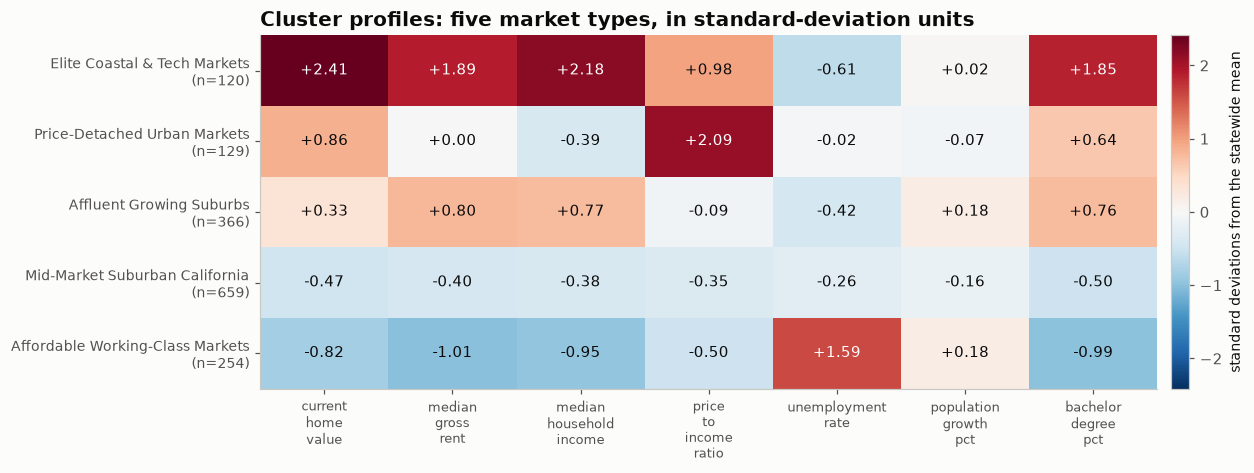

In [24]:
# ---- Figure 10: cluster profile heatmap ---------------------------------------------------------
z = pd.DataFrame(km.cluster_centers_, columns=CLUSTER_FEATURES).rename(index=NAMES)
z = z.loc[[NAMES[i] for i in sorted(NAMES, key=lambda c: -profile.loc[c, "current_home_value"])]]

fig, ax = plt.subplots(figsize=(11.5, 4.4))
lim = np.abs(z.values).max()
im = ax.imshow(z.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        v = z.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9.5,
                color="white" if abs(v) > 0.62 * lim else "#0b0b0b")
ax.set_xticks(range(len(CLUSTER_FEATURES)))
ax.set_xticklabels([c.replace("_", "\n") for c in CLUSTER_FEATURES], fontsize=8.5)
ax.set_yticks(range(len(z)))
ax.set_yticklabels([f"{n}\n(n={profile.loc[[k for k, v in NAMES.items() if v == n][0], 'n']:,.0f})"
                    for n in z.index], fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.015)
cb.set_label("standard deviations from the statewide mean", fontsize=9)
ax.set_title("Cluster profiles: five market types, in standard-deviation units")
fig.tight_layout()
save(fig, "fig10_cluster_profiles")
plt.show()

**Figure 10.** Read the rows against the colour scale. Elite Coastal & Tech is red across the board —
the affluence ladder's top rung. Affordable Working-Class is its mirror image, blue everywhere except
unemployment. Mid-Market Suburban is pale everywhere, which is what makes it the centre of the
distribution rather than a distinctive type.

**The Price-Detached row is the one that could not exist on a one-dimensional scale**: deep red on
`price_to_income_ratio` (+2.09) and `current_home_value` (+0.86), but **blue on
`median_household_income` (−0.39)**. No affluence ordering can produce that pattern.

explained variance ratio: [0.5312 0.1613 0.1469 0.0943 0.034  0.0271 0.0051]
PC1 + PC2 retain 69.3% of the variance in the 7 scaled features

                           PC1    PC2
current_home_value       0.476  0.218
median_gross_rent        0.455 -0.210
median_household_income  0.454 -0.309
price_to_income_ratio    0.264  0.641
unemployment_rate       -0.268  0.049
population_growth_pct    0.015 -0.632
bachelor_degree_pct      0.468 -0.031


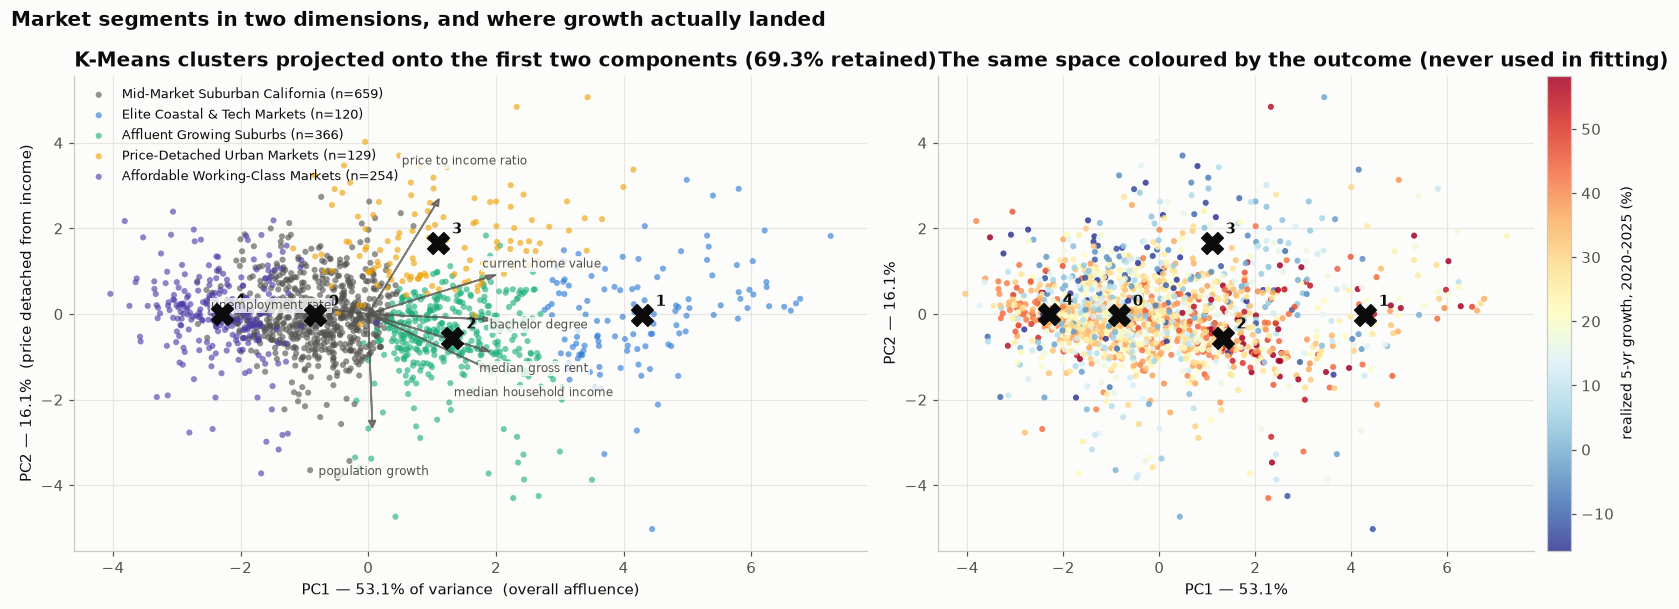

In [25]:
# ---- Figure 11: PCA projection -----------------------------------------------------------------
pca = PCA(n_components=len(CLUSTER_FEATURES), random_state=RANDOM_STATE).fit(Xc)
XY = pca.transform(Xc)
evr = pca.explained_variance_ratio_
print("explained variance ratio:", np.round(evr, 4))
print(f"PC1 + PC2 retain {evr[:2].sum():.1%} of the variance in the 7 scaled features\n")
loadings = pd.DataFrame(pca.components_[:2].T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
print(loadings.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
for c in sorted(NAMES):
    m = snap.cluster.values == c
    ax.scatter(XY[m, 0], XY[m, 1], s=16, alpha=0.62, color=CATEGORICAL[c],
               label=f"{NAMES[c]} (n={m.sum()})", edgecolor="none")
cen = pca.transform(km.cluster_centers_)
ax.scatter(cen[:, 0], cen[:, 1], marker="X", s=200, color="#0b0b0b", zorder=6)
for c in sorted(NAMES):
    ax.annotate(str(c), (cen[c, 0], cen[c, 1]), textcoords="offset points", xytext=(9, 6),
                fontsize=10, fontweight="bold")
for f in CLUSTER_FEATURES:
    ax.arrow(0, 0, loadings.loc[f, "PC1"] * 4.2, loadings.loc[f, "PC2"] * 4.2,
             color=GRAY, lw=1.1, alpha=0.75, head_width=0.11, length_includes_head=True)
    ax.text(loadings.loc[f, "PC1"] * 5.7, loadings.loc[f, "PC2"] * 5.7 - 0.16,
            f.replace("_pct", "").replace("_", " "), fontsize=7.6, color=GRAY, ha="center",
            bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=0.9, alpha=0.8))
ax.set_xlabel(f"PC1 — {evr[0]:.1%} of variance  (overall affluence)")
ax.set_ylabel(f"PC2 — {evr[1]:.1%}  (price detached from income)")
ax.set_title(f"K-Means clusters projected onto the first two components ({evr[:2].sum():.1%} retained)")
ax.legend(fontsize=8.4, loc="upper left")

ax = axes[1]
sc = ax.scatter(XY[:, 0], XY[:, 1], c=snap[TARGET], cmap="RdYlBu_r", s=16, alpha=0.85,
                vmin=snap[TARGET].quantile(0.02), vmax=snap[TARGET].quantile(0.98),
                edgecolor="none")
ax.scatter(cen[:, 0], cen[:, 1], marker="X", s=200, color="#0b0b0b", zorder=6)
for c in sorted(NAMES):
    ax.annotate(str(c), (cen[c, 0], cen[c, 1]), textcoords="offset points", xytext=(9, 6),
                fontsize=10, fontweight="bold")
cb = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("realized 5-yr growth, 2020-2025 (%)", fontsize=9)
ax.set_xlabel(f"PC1 — {evr[0]:.1%}"); ax.set_ylabel(f"PC2 — {evr[1]:.1%}")
ax.set_title("The same space coloured by the outcome (never used in fitting)")

fig.suptitle("Market segments in two dimensions, and where growth actually landed",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig11_pca_clusters")
plt.show()

**Figure 11 — and what "69.3% of the variance" does and does not license.**

PC1 retains **53.1%** and PC2 **16.1%**, so the plot preserves **69.3%** of the variance in the seven
scaled features. The remaining 30.7% is *not* visible: two points that appear adjacent may be separated
along PC3–PC7. The projection is a faithful summary, not the clustering itself — K-Means ran in all
seven dimensions.

The loadings name the axes:

- **PC1** loads +0.48 value, +0.46 rent, +0.45 income, +0.47 education, −0.27 unemployment — a single
  **overall affluence** axis, and the reason k=2 scores so well on silhouette.
- **PC2** loads **+0.64 price-to-income** against **−0.63 population growth** and −0.31 income. This is
  the **"price detached from local earnings"** axis, and it is what k=3 cannot use.

The right-hand panel adds the outcome as colour, *after* fitting. Blue (low growth) concentrates in the
upper region — high PC2 — which is where the Price-Detached cluster sits. That visual impression is
quantified next.

## 3.5 Linking the segments back to growth

The connection is made in two ways: (a) within the 2020 slice that was clustered, and (b) by assigning
**every** base year's ZIP codes to the 2020-fitted centroids and asking whether the ordering repeats
across five independent five-year windows. The second is much the stronger test — a segment that ranks
last in 2016, 2017, 2018, 2019 *and* 2020 is not a fluke of one period.

In [26]:
groups_g = [g[TARGET].values for _, g in snap.groupby("cluster")]
F, p_anova = stats.f_oneway(*groups_g)
H = stats.kruskal(*groups_g)
print(f"2020 slice -- one-way ANOVA across the {K_CHOSEN} segments:"
      f"  F = {F:.2f},  p = {p_anova:.2e}")
print(f"                Kruskal-Wallis (no normality assumption):  p = {H.pvalue:.2e}")
print(f"\nWelch t-tests, {NAMES[id_stretched]} vs each other segment:")
for c in sorted(NAMES):
    if c == id_stretched:
        continue
    t = stats.ttest_ind(snap.loc[snap.cluster == id_stretched, TARGET],
                        snap.loc[snap.cluster == c, TARGET], equal_var=False)
    print(f"  vs {NAMES[c]:<34} p = {t.pvalue:.2e}")

2020 slice -- one-way ANOVA across the 5 segments:  F = 27.49,  p = 4.63e-22
                Kruskal-Wallis (no normality assumption):  p = 2.19e-17

Welch t-tests, Price-Detached Urban Markets vs each other segment:
  vs Mid-Market Suburban California     p = 5.06e-09
  vs Elite Coastal & Tech Markets       p = 2.30e-08
  vs Affluent Growing Suburbs           p = 3.48e-16
  vs Affordable Working-Class Markets   p = 8.47e-09


In [27]:
# Assign every base year to the 2020-fitted segmentation. The scaler and centroids are NOT refitted.
allp = panel.copy()
allp["cluster"] = km.predict(scaler_c.transform(allp[CLUSTER_FEATURES].clip(lo_q, hi_q, axis=1)))
allp["segment"] = allp["cluster"].map(NAMES)
allp["growth_rel"] = allp[TARGET] - allp.groupby("base_year")[TARGET].transform("median")

by_year = allp.pivot_table(index="segment", columns="base_year", values=TARGET, aggfunc="mean")
ranks = by_year.rank(ascending=False).astype(int)
summary = allp.groupby("segment").agg(
    n=("zip_code", "size"),
    mean_growth=(TARGET, "mean"),
    rel_growth_mean=("growth_rel", "mean"),
    rel_growth_median=("growth_rel", "median"),
    top_quartile_rate=("high_growth_rel", "mean"),
).sort_values("rel_growth_mean", ascending=False)

print("Mean realized 5-yr growth by segment and base year (%)")
print(by_year.round(2).to_string())
print("\nRank within each base year (1 = fastest growing)")
print(ranks.to_string())
print("\nPooled across all five base years, relative to each year's own median")
print(summary.round(3).to_string())

Mean realized 5-yr growth by segment and base year (%)
base_year                          2016   2017   2018   2019   2020
segment                                                            
Affluent Growing Suburbs         51.660 45.050 38.600 43.600 29.560
Affordable Working-Class Markets 67.150 56.830 44.230 40.900 24.410
Elite Coastal & Tech Markets     51.360 40.740 27.460 34.280 26.660
Mid-Market Suburban California   55.360 47.790 39.680 38.220 23.320
Price-Detached Urban Markets     42.840 34.560 22.220 20.470 12.090

Rank within each base year (1 = fastest growing)
base_year                         2016  2017  2018  2019  2020
segment                                                       
Affluent Growing Suburbs             3     3     3     1     1
Affordable Working-Class Markets     1     1     1     2     3
Elite Coastal & Tech Markets         4     4     4     4     2
Mid-Market Suburban California       2     2     2     3     4
Price-Detached Urban Markets         5   

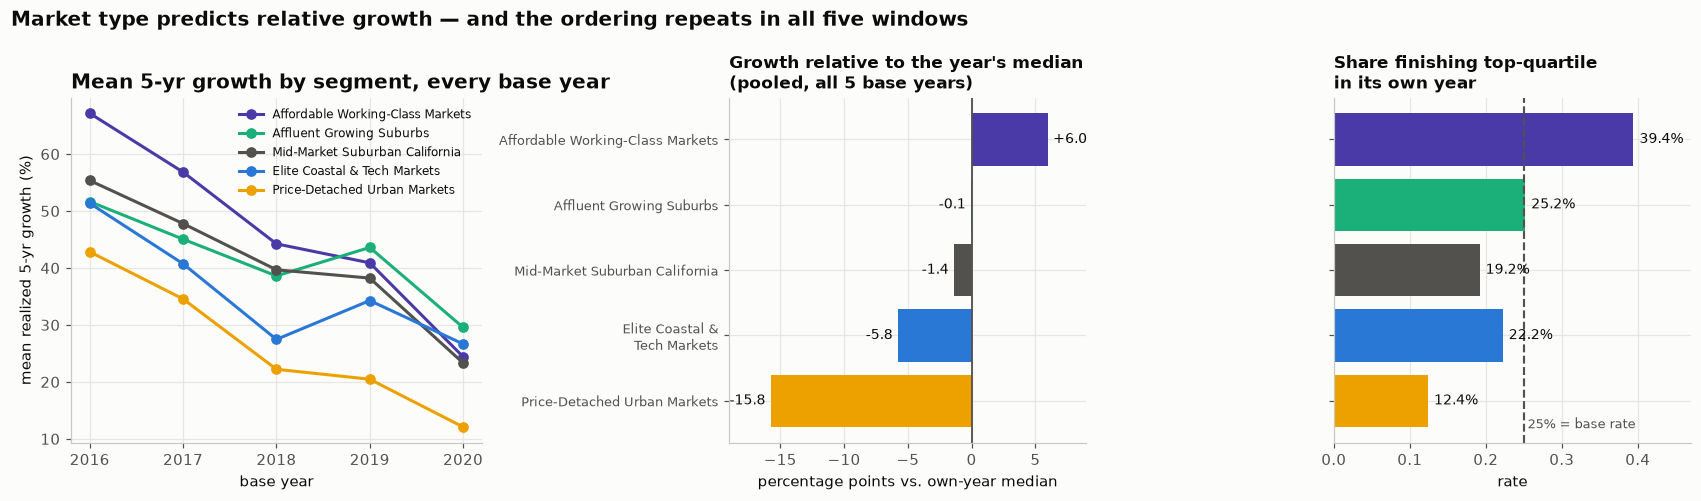

In [28]:
# ---- Figure 12: do market types systematically outgrow each other? -----------------------------
ordered = summary.index.tolist()
cmap_seg = {NAMES[c]: CATEGORICAL[c] for c in sorted(NAMES)}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), gridspec_kw={"width_ratios": [1.15, 1, 1]})

ax = axes[0]
for seg in ordered:
    ax.plot(by_year.columns, by_year.loc[seg], marker="o", lw=2, color=cmap_seg[seg], label=seg)
ax.set_title("Mean 5-yr growth by segment, every base year")
ax.set_xlabel("base year"); ax.set_ylabel("mean realized 5-yr growth (%)")
ax.set_xticks(by_year.columns)
ax.legend(fontsize=7.8, loc="upper right")

ax = axes[1]
vals = summary["rel_growth_mean"]
ax.barh(range(len(vals)), vals.values[::-1],
        color=[cmap_seg[s] for s in vals.index[::-1]])
for i, v in enumerate(vals.values[::-1]):
    ax.text(v + (0.4 if v >= 0 else -0.4), i, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color=GRAY, lw=1.2)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels([s.replace(" & ", " &\n").replace("Markets", "Markets")
                    for s in vals.index[::-1]], fontsize=8.2)
ax.set_xlim(-19, 9)
ax.set_title("Growth relative to the year's median\n(pooled, all 5 base years)", fontsize=11)
ax.set_xlabel("percentage points vs. own-year median")

ax = axes[2]
r = summary["top_quartile_rate"]
ax.barh(range(len(r)), r.values[::-1], color=[cmap_seg[s] for s in r.index[::-1]])
ax.axvline(0.25, color=GRAY, lw=1.4, ls="--")
ax.text(0.255, -0.42, "25% = base rate", color=GRAY, fontsize=8.5)
for i, v in enumerate(r.values[::-1]):
    ax.text(v + 0.008, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_yticks(range(len(r))); ax.set_yticklabels([])
ax.set_xlim(0, 0.47)
ax.set_title("Share finishing top-quartile\nin its own year", fontsize=11)
ax.set_xlabel("rate")

fig.suptitle("Market type predicts relative growth — and the ordering repeats in all five windows",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig12_cluster_growth")
plt.show()

**Figure 12 — the result that connects clustering back to the project's core question.**

**Yes, market types systematically outgrew one another, and the ordering is stable.**

| Segment | vs. own-year median | Top-quartile rate | Rank in 2016 / 17 / 18 / 19 / 20 |
|---|---|---|---|
| **Affordable Working-Class Markets** | **+5.99 pts** | **39.4%** | 1, 1, 1, 2, 3 |
| Affluent Growing Suburbs | −0.05 | 25.2% | 3, 3, 3, **1**, **1** |
| Mid-Market Suburban California | −1.39 | 19.2% | 2, 2, 2, 3, 4 |
| Elite Coastal & Tech Markets | −5.78 | 22.2% | 4, 4, 4, 4, 2 |
| **Price-Detached Urban Markets** | **−15.76 pts** | **12.4%** | **5, 5, 5, 5, 5** |

- **Price-Detached Urban Markets finished last in every one of the five windows** — 686 ZIP-years,
  averaging **15.8 points below** their own year's median, with a top-quartile rate of 12.4% (half the
  base rate). ANOVA across segments on the 2020 slice gives **F = 27.49, p = 4.6 × 10⁻²²**; every
  pairwise Welch test against this segment clears p < 10⁻⁸.
- **Affordable Working-Class Markets ran +6.0 points above median** and hit top-quartile 39.4% of the
  time — 1.6× the base rate.
- The spread between best and worst segment is **21.8 percentage points of five-year growth.**

**The essential caveat, stated plainly.** `price_to_income_ratio` is one of the seven clustering
features, and D2 already identified affordability as the strongest stable predictor of relative growth.
So "the extreme price-to-income segment underperformed" is **the affordability finding re-derived by an
unsupervised method, not independent confirmation of it**. What clustering adds is that the effect is
*segment-level and categorical*: it is not a smooth gradient across all ZIP codes but a specific,
identifiable, 129-ZIP type of market — expensive homes in neighbourhoods whose residents do not earn
enough to buy them — that behaved differently from everything else, in every period observed.

One genuine surprise: **Elite Coastal & Tech Markets also underperformed** (−5.78 points), despite
being the most affluent segment by a wide margin. Wealth did not protect against slow appreciation;
these markets were already priced at 11.8× income in 2020 and had the least room left to run. That is
consistent with the affordability story rather than a counterexample to it — and note the rank
reversal in 2020, where the elite segment jumped to 2nd. Segment orderings are stable, not permanent.

---
# 4. Association rule mining — which combinations of conditions co-occur with high growth?

## 4.1 What the three metrics mean, in plain language

For a rule **{A, B} → {C}**:

| Metric | Formula | Plain reading | What is a good value |
|---|---|---|---|
| **Support** | P(A ∧ B ∧ C) | How often the whole pattern occurs in the data | Must be large enough to be worth acting on. 0.05 = 374 of 7,487 ZIP-years |
| **Confidence** | P(C \| A ∧ B) | When A and B hold, how often does C follow? | Compare it to the base rate of C, never to 100% |
| **Lift** | confidence ÷ P(C) | How much more often than *chance* | **1.0 = the rule tells you nothing.** Above ~1.2 is worth reading |

**Lift is the metric that matters, and it is the one that catches worthless rules.** With growth split
into three equal terciles, P(C) = 1/3 for any growth bin. A rule with 60% confidence therefore has lift
1.8 — genuinely informative. But if a consequent occurred 60% of the time on its own, that same 60%
confidence would carry lift 1.0 and mean *nothing*: the antecedent would have added no information.
Confidence alone cannot distinguish those two cases; lift can.

## 4.2 Building transactions

Each ZIP-year becomes one transaction — a basket of discretized conditions. Eight continuous variables
are cut into terciles labelled Low / Med / High, reusing the discretization technique from Lab 1:

```
["Income=Low", "PriceToIncome=Low", "Unemployment=High",
 "Education=Low", "PopGrowth=Med", "Momentum=High", "FutureGrowth=High"]
```

One-hot encoding turns that into a boolean matrix of 7,487 rows × 24 columns for Apriori.

In [29]:
SHORT = {
    "median_household_income": "Income",
    "price_to_income_ratio":   "PriceToIncome",
    "unemployment_rate":       "Unemployment",
    "bachelor_degree_pct":     "Education",
    "population_growth_pct":   "PopGrowth",
    "home_value_1yr_growth_pct": "Momentum",
    "mortgage_rate":           "MortgageRate",
    TARGET:                    "FutureGrowth",
}
BIN_COLS = list(SHORT)


def build_transactions(df, cols, growth_within_year=False):
    """Tercile-discretize each column and one-hot encode. Returns a boolean DataFrame."""
    parts = []
    for c in cols:
        if c == TARGET and growth_within_year:
            b = df.groupby("base_year")[c].transform(
                lambda s: pd.qcut(s, 3, labels=["Low", "Med", "High"]))
        else:
            b = pd.qcut(df[c], 3, labels=["Low", "Med", "High"])
        parts.append(b.rename(SHORT[c]))
    oh = pd.get_dummies(pd.concat(parts, axis=1))
    oh.columns = [c.replace("_", "=") for c in oh.columns]
    return oh.astype(bool)


onehot = build_transactions(panel, BIN_COLS, growth_within_year=False)
print(f"transaction matrix: {onehot.shape[0]:,} transactions x {onehot.shape[1]} items")
print("items:", ", ".join(onehot.columns[:8]), "...")
print("\nexample transaction (row 0):")
print(" ", [c for c in onehot.columns if onehot.iloc[0][c]])

print("\ntercile boundaries -- what Low/Med/High actually mean:")
bounds = pd.DataFrame({SHORT[c]: panel[c].quantile([1/3, 2/3]).values for c in BIN_COLS},
                      index=["Low | Med", "Med | High"]).T
print(bounds.round(2).to_string())

transaction matrix: 7,487 transactions x 24 items
items: Income=Low, Income=Med, Income=High, PriceToIncome=Low, PriceToIncome=Med, PriceToIncome=High, Unemployment=Low, Unemployment=Med ...

example transaction (row 0):
  ['Income=Low', 'PriceToIncome=High', 'Unemployment=High', 'Education=Low', 'PopGrowth=Med', 'Momentum=High', 'MortgageRate=Low', 'FutureGrowth=High']

tercile boundaries -- what Low/Med/High actually mean:
               Low | Med  Med | High
Income        55,947.330  81,916.000
PriceToIncome      6.050       8.840
Unemployment       5.200       8.090
Education         19.990      39.180
PopGrowth          0.420       5.550
Momentum           5.150       9.260
MortgageRate       3.650       3.990
FutureGrowth      33.780      49.580


## 4.3 Run 1 — the plan exactly as written, and the trap it walks into

`min_support=0.05`, `min_confidence=0.60`, `lift ≥ 1.20`, keeping only rules whose **consequent is a
future-growth bin**. Rules like `{Income=High} → {Education=High}` are true, trivial and worthless; the
filter removes them.

In [30]:
def mine_rules(oh, min_support=0.05, min_confidence=0.60, min_lift=1.20, max_len=4):
    freq = apriori(oh, min_support=min_support, use_colnames=True, max_len=max_len)
    rules = association_rules(freq, num_itemsets=len(oh),
                              metric="confidence", min_threshold=min_confidence)
    kept = rules[rules["lift"] >= min_lift]
    growth = kept[kept["consequents"].apply(
        lambda s: all(i.startswith("FutureGrowth") for i in s))].copy()
    if len(growth):
        growth["antecedent"] = growth["antecedents"].apply(lambda s: " & ".join(sorted(s)))
        growth["consequent"] = growth["consequents"].apply(lambda s: " & ".join(sorted(s)))
        growth = growth.sort_values("lift", ascending=False)
    print(f"frequent itemsets (support >= {min_support})      : {len(freq):,}")
    print(f"rules (confidence >= {min_confidence})                 : {len(rules):,}")
    print(f"  ... of which lift >= {min_lift}                : {len(kept):,}")
    print(f"  ... of which the consequent is a growth bin : {len(growth):,}")
    return growth, rules, freq


COLS = ["antecedent", "consequent", "support", "confidence", "lift"]
rules1, all1, freq1 = mine_rules(onehot)
print()
print(rules1[COLS].to_string(index=False))

frequent itemsets (support >= 0.05)      : 567
rules (confidence >= 0.6)                 : 248
  ... of which lift >= 1.2                : 248
  ... of which the consequent is a growth bin : 4

                                           antecedent        consequent  support  confidence  lift
   Income=Low & PriceToIncome=Low & Unemployment=High FutureGrowth=High    0.068       0.651 1.954
Education=Low & PriceToIncome=Low & Unemployment=High FutureGrowth=High    0.077       0.635 1.904
 Education=Low & MortgageRate=Med & Unemployment=High FutureGrowth=High    0.050       0.609 1.826
       Education=Low & Income=Low & PriceToIncome=Low FutureGrowth=High    0.072       0.608 1.823


In [31]:
print("mortgage_rate is constant within a base year -- five values across 7,487 rows:")
print(panel.groupby("base_year")["mortgage_rate"].first().round(3).to_string())
print("\nSo its terciles ARE base years:")
print(pd.crosstab(panel["base_year"],
                  pd.qcut(panel["mortgage_rate"], 3, labels=["Low", "Med", "High"])).to_string())
print("\nAnd global growth terciles are almost base years too:")
print(pd.crosstab(panel["base_year"],
                  pd.qcut(panel[TARGET], 3, labels=["Low", "Med", "High"])).to_string())

mortgage_rate is constant within a base year -- five values across 7,487 rows:
base_year
2016   3.654
2017   3.990
2018   4.545
2019   3.936
2020   3.112

So its terciles ARE base years:
mortgage_rate   Low   Med  High
base_year                      
2016           1452     0     0
2017              0  1496     0
2018              0     0  1500
2019              0  1511     0
2020           1528     0     0

And global growth terciles are almost base years too:
future_5yr_growth_pct   Low  Med  High
base_year                             
2016                     97  408   947
2017                    258  526   712
2018                    521  632   347
2019                    537  552   422
2020                   1083  377    68


### Why run 1 produces four rules, one of which is meaningless

Only **4 rules** survive, and the diagnostic cross-tabs above explain both the scarcity and the quality:

**`MortgageRate` terciles are a `base_year` index.** The rate is national and constant within a year
(3.65 / 3.99 / 4.54 / 3.94 / 3.11), so its Low tercile is exactly {2016, 2020}, Med is {2017, 2019},
High is {2018} — a perfect partition of years, 1,452/1,496/1,500/1,511/1,528 rows with no mixing at
all. The rule

> `{Education=Low, MortgageRate=Med, Unemployment=High} → {FutureGrowth=High}` (conf 0.609, lift 1.83)

therefore reads, once decoded: *"in 2017 or 2019, low-education high-unemployment ZIPs grew fast."*
The `MortgageRate` term contributes no market information; it silently conditions on a year. **This is
exactly the failure D2 §9.8 warned about, now appearing in a completely different algorithm.**

**Global growth terciles are also nearly a `base_year` index.** The FutureGrowth=High tercile is
**947 of 1,452 rows in 2016** and **68 of 1,528 in 2020**. So "high growth" as a global bin largely
means "observed in 2016 or 2017" — the same regime shift that emptied the classification label in §2.2,
in a third guise.

The three rules that do *not* mention the rate are still substantively right — low income, low
price-to-income and high unemployment together reach **lift 1.95**, the highest in the run — but they
are contaminated by the same year effect in the consequent.

## 4.4 Run 2 — remove the base-year proxies

Two changes, both following directly from the diagnosis:

1. **Drop `mortgage_rate` from the item set.** It is a year label wearing a feature's name.
2. **Cut the growth terciles *within* each base year**, the same repair applied to the classification
   label in §2.7. Now `FutureGrowth=High` means "top third **of its own period**", which is exactly 1/3
   of every year by construction, and a rule that mentions it cannot be secretly reporting a year.

**One threshold is relaxed and it should be stated openly.** Confidence goes from 0.60 to **0.50**.
After removing the year effect no conjunction of market conditions reaches 0.60 confidence except three
— the year effect was doing much of the work in run 1. With three equal terciles the base rate is
**33.3%**, so a 0.50 confidence floor is already a **1.5× lift floor**: every rule reported below is at
least 50% more likely than chance to be right. The `lift ≥ 1.20` filter is unchanged.

In [32]:
COLS2 = [c for c in BIN_COLS if c != "mortgage_rate"]
onehot2 = build_transactions(panel, COLS2, growth_within_year=True)
print(f"transaction matrix: {onehot2.shape[0]:,} x {onehot2.shape[1]}  (mortgage_rate dropped)")
print("FutureGrowth bins are now exactly one-third of every base year:")
print(pd.crosstab(panel["base_year"],
                  panel.groupby("base_year")[TARGET].transform(
                      lambda s: pd.qcut(s, 3, labels=["Low", "Med", "High"]))).to_string())
print()
rules2, all2, freq2 = mine_rules(onehot2, min_confidence=0.50)

transaction matrix: 7,487 x 21  (mortgage_rate dropped)
FutureGrowth bins are now exactly one-third of every base year:
future_5yr_growth_pct  Low  Med  High
base_year                            
2016                   484  484   484
2017                   499  498   499
2018                   500  500   500
2019                   504  503   504
2020                   510  509   509

frequent itemsets (support >= 0.05)      : 377
rules (confidence >= 0.5)                 : 350
  ... of which lift >= 1.2                : 350
  ... of which the consequent is a growth bin : 26


In [33]:
print("ALL SURVIVING RULES BY LIFT  (consequent = a within-year future-growth tercile)\n")
print(rules2[COLS].to_string(index=False))
print("\nrules by consequent:", rules2["consequent"].value_counts().to_dict())
print(f"\nlift range: {rules2['lift'].min():.3f} to {rules2['lift'].max():.3f}")
print(f"support range: {rules2['support'].min():.3f} to {rules2['support'].max():.3f}"
      f"   ({rules2['support'].min() * len(panel):,.0f} to "
      f"{rules2['support'].max() * len(panel):,.0f} ZIP-years)")

for con in ["FutureGrowth=High", "FutureGrowth=Low"]:
    sub = rules2[rules2.consequent == con]
    n = sub["antecedent"].str.contains("PriceToIncome").sum()
    print(f"  {con}: {len(sub)} rules, {n} of them mention PriceToIncome")

ALL SURVIVING RULES BY LIFT  (consequent = a within-year future-growth tercile)

                                            antecedent        consequent  support  confidence  lift
    Income=Low & PriceToIncome=Low & Unemployment=High FutureGrowth=High    0.066       0.625 1.874
        Education=Low & Income=Low & PriceToIncome=Low FutureGrowth=High    0.073       0.616 1.847
 Education=Low & PriceToIncome=Low & Unemployment=High FutureGrowth=High    0.073       0.605 1.814
                   PopGrowth=High & PriceToIncome=High  FutureGrowth=Low    0.057       0.593 1.779
    Education=High & Momentum=Low & PriceToIncome=High  FutureGrowth=Low    0.051       0.593 1.778
     Education=Low & Momentum=High & Unemployment=High FutureGrowth=High    0.058       0.589 1.766
        Education=Low & Income=Low & Unemployment=High FutureGrowth=High    0.097       0.588 1.765
                        Income=Low & PriceToIncome=Low FutureGrowth=High    0.081       0.569 1.708
                   

### Which *single* conditions carry information, before any conjunction

The rules above are all conjunctions. It is worth asking what each individual condition is worth on its
own — the answer clarifies which variables the conjunctions are actually built from.

In [34]:
single = association_rules(freq2, num_itemsets=len(onehot2), metric="confidence", min_threshold=0.0)
single = single[(single["antecedents"].apply(len) == 1) &
                (single["consequents"].apply(lambda s: all(i.startswith("FutureGrowth") for i in s)))].copy()
single["condition"] = single["antecedents"].apply(lambda s: list(s)[0])
single["growth bin"] = single["consequents"].apply(lambda s: list(s)[0])
lift_tbl = single.pivot_table(index="condition", columns="growth bin", values="lift")
print("Lift of each single condition against each growth tercile  (1.00 = no information)")
print(lift_tbl.round(3).to_string())

print("\nStrongest single conditions:")
for con in ["FutureGrowth=High", "FutureGrowth=Low"]:
    top = lift_tbl[con].sort_values(ascending=False).head(4)
    print(f"  -> {con}: " + ",  ".join(f"{k} ({v:.2f})" for k, v in top.items()))

for c, b in [("PriceToIncome=High", "FutureGrowth=Low"), ("PriceToIncome=Low", "FutureGrowth=High")]:
    row = single[(single.condition == c) & (single["growth bin"] == b)].iloc[0]
    print(f"\n{{{c}}} -> {{{b}}}   support {row.support:.3f}"
          f"  ({row.support * len(panel):,.0f} ZIP-years)"
          f"  confidence {row.confidence:.3f}  lift {row.lift:.3f}")

Lift of each single condition against each growth tercile  (1.00 = no information)
growth bin          FutureGrowth=High  FutureGrowth=Low  FutureGrowth=Med
condition                                                                
Education=High                  0.850             1.285             0.865
Education=Low                   1.428             0.586             0.986
Education=Med                   0.723             1.128             1.149
Income=High                     0.874             1.115             1.011
Income=Low                      1.262             0.852             0.886
Income=Med                      0.864             1.034             1.102
Momentum=High                   1.120             0.832             1.048
Momentum=Low                    0.961             1.166             0.872
Momentum=Med                    0.919             1.001             1.080
PopGrowth=High                  0.948             1.102             0.950
PopGrowth=Low                

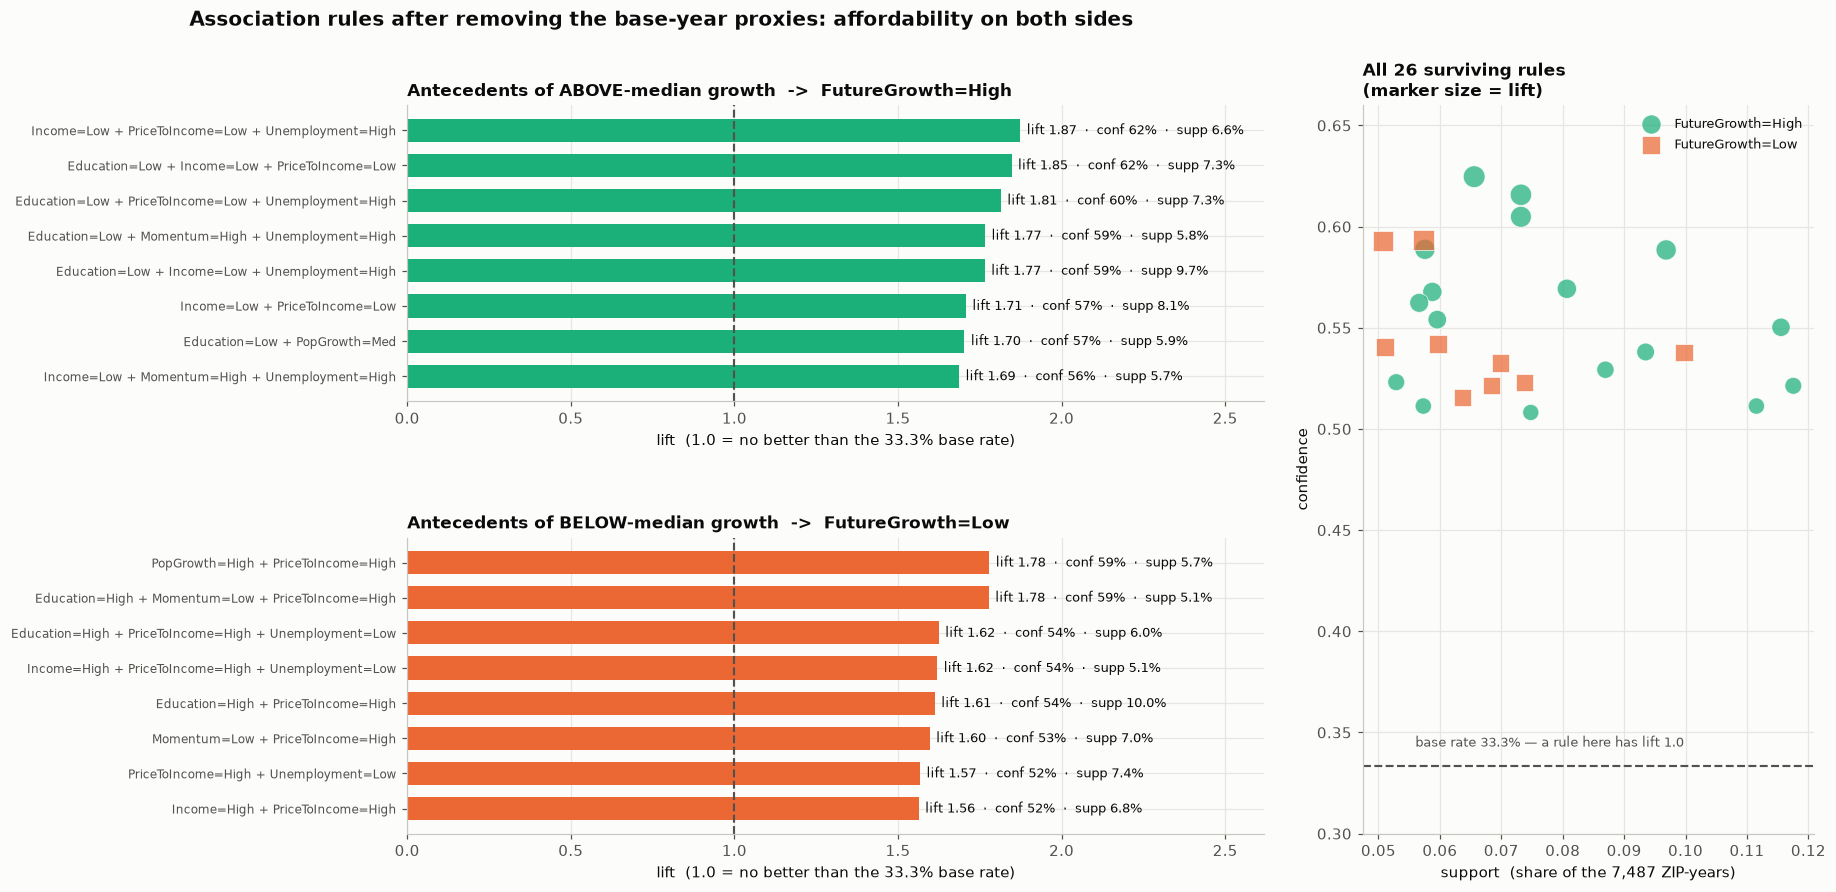

In [35]:
# ---- Figure 13: the rules -----------------------------------------------------------------------
top_hi = rules2[rules2.consequent == "FutureGrowth=High"].head(8)
top_lo = rules2[rules2.consequent == "FutureGrowth=Low"].head(8)

fig = plt.figure(figsize=(16.5, 8.6))
gs_ = fig.add_gridspec(2, 2, width_ratios=[1.9, 1], hspace=0.46, wspace=0.15)

def rule_bars(ax, df, color, title):
    lab = [a.replace(" & ", " + ") for a in df["antecedent"]][::-1]
    ax.barh(range(len(df)), df["lift"].values[::-1], color=color, height=0.66)
    for i, (l, c, s) in enumerate(zip(df["lift"].values[::-1], df["confidence"].values[::-1],
                                      df["support"].values[::-1])):
        ax.text(l + 0.02, i, f"lift {l:.2f}  ·  conf {c:.0%}  ·  supp {s:.1%}",
                va="center", fontsize=8.4)
    ax.set_yticks(range(len(df))); ax.set_yticklabels(lab, fontsize=8.0)
    ax.axvline(1.0, color=GRAY, lw=1.4, ls="--")
    ax.set_xlim(0, 2.62)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("lift  (1.0 = no better than the 33.3% base rate)")

rule_bars(fig.add_subplot(gs_[0, 0]), top_hi, GREEN,
          "Antecedents of ABOVE-median growth  ->  FutureGrowth=High")
rule_bars(fig.add_subplot(gs_[1, 0]), top_lo, ACCENT,
          "Antecedents of BELOW-median growth  ->  FutureGrowth=Low")

ax = fig.add_subplot(gs_[:, 1])
for con, color, mark in [("FutureGrowth=High", GREEN, "o"), ("FutureGrowth=Low", ACCENT, "s")]:
    d = rules2[rules2.consequent == con]
    ax.scatter(d["support"], d["confidence"], s=28 + (d["lift"] - 1.2) * 260, marker=mark,
               color=color, alpha=0.72, edgecolor="white", lw=0.6, label=con)
ax.axhline(1 / 3, color=GRAY, lw=1.4, ls="--")
ax.text(0.056, 0.343, "base rate 33.3% — a rule here has lift 1.0", color=GRAY, fontsize=8.4)
ax.set_xlabel("support  (share of the 7,487 ZIP-years)")
ax.set_ylabel("confidence")
ax.set_ylim(0.30, 0.66)
ax.set_title(f"All {len(rules2)} surviving rules\n(marker size = lift)", fontsize=11)
ax.legend(fontsize=8.5, loc="upper right")

fig.suptitle("Association rules after removing the base-year proxies: affordability on both sides",
             x=0.005, ha="left", fontweight="bold", fontsize=13)
save(fig, "fig13_association_rules")
plt.show()

### What the 26 rules say

They are not weak, and they are strikingly one-note. **17 rules predict High growth, 9 predict Low, and
not a single rule predicts the middle tercile** — conjunctions of extreme conditions push outcomes to
the tails, and nothing identifies an average market. Lift runs from **1.52 to 1.87** on supports of
**5.1% to 11.8%** (380 to 880 ZIP-years), so these are patterns with real mass behind them, not
curiosities found in a handful of rows.

**The strongest High-growth rules**

| Rule | Support | Confidence | Lift |
|---|---|---|---|
| `{Income=Low, PriceToIncome=Low, Unemployment=High} → High` | 6.6% | 62.5% | **1.87** |
| `{Education=Low, Income=Low, PriceToIncome=Low} → High` | 7.3% | 61.6% | **1.85** |
| `{Education=Low, PriceToIncome=Low, Unemployment=High} → High` | 7.3% | 60.5% | **1.81** |
| `{Education=Low, Momentum=High, Unemployment=High} → High` | 5.8% | 58.9% | 1.77 |
| `{Income=Low, PriceToIncome=Low} → High` | 8.1% | 56.9% | 1.71 |

**The strongest Low-growth rules**

| Rule | Support | Confidence | Lift |
|---|---|---|---|
| `{PopGrowth=High, PriceToIncome=High} → Low` | 5.7% | 59.3% | **1.78** |
| `{Education=High, Momentum=Low, PriceToIncome=High} → Low` | 5.1% | 59.3% | **1.78** |
| `{Education=High, PriceToIncome=High, Unemployment=Low} → Low` | 6.0% | 54.2% | 1.62 |
| `{Income=High, PriceToIncome=High, Unemployment=Low} → Low` | 5.1% | 54.0% | 1.62 |
| `{Education=High, PriceToIncome=High} → Low` | 10.0% | 53.8% | 1.61 |

**`PriceToIncome=High` appears in every single one of the 9 Low-growth rules**, and `PriceToIncome=Low`
in 7 of the 17 High-growth rules (4 of the top 8) — the same variable on both tails, with opposite
polarity.

The single-condition table sharpens this rather than merely repeating it, and the two tails are not
symmetric:

- **For Low growth, `PriceToIncome=High` is the strongest single condition in the entire item set**
  (lift **1.414**, confidence 47.2%, support **15.7%** = 1,177 ZIP-years). No conjunction is needed;
  the one condition carries the signal, and the conjunctions merely sharpen it from 1.41 to 1.78.
- **For High growth it is not.** `PriceToIncome=Low` alone reaches only lift **1.225** — 4th, behind
  `Education=Low` (1.428), `Unemployment=High` (1.324) and `Income=Low` (1.262). Affordability alone
  does not identify a winner; it has to be *combined* with the low-income, high-unemployment profile
  before lift reaches 1.87.

In plain terms: **being unaffordable was sufficient on its own to predict underperformance; being
affordable was not sufficient on its own to predict outperformance.** That asymmetry is the most
practically useful thing in this section, and it would have been invisible from the conjunction rules
alone.

**A third independent method has now landed on affordability.** D2's regression put the largest stable
standardized coefficients on the affordability ratios; §3.5's unsupervised clusters isolated a
price-detached segment that finished last in all five windows; and Apriori — which knows nothing about
regression, nothing about distance, and sees only co-occurrence counts over discretized bins — ranks
price-to-income first on both tails. **Three algorithms with nothing in common agreeing on one variable
is the strongest evidence in this project.**

**And a caution that goes with it.** Conditioning is not causation, and the High-growth antecedents are
telling: `Income=Low`, `Education=Low`, `Unemployment=High` recur throughout. These describe the
*Affordable Working-Class Markets* segment from §3.4 — Bakersfield, Fresno, Rialto. The rules do not
say that low income causes appreciation. They say **cheap markets appreciated faster in percentage
terms from 2016–2020**, which is partly an arithmetic property of small denominators and partly the
pandemic-era migration to lower-cost inland California. A 30% gain on a $285,000 home is $85,500; the
same 30% on the $1.7M Elite Coastal median is $511,000. **Percentage growth and dollar gains are not
the same thing, and these rules are about the former.**

## 4.5 What three different readers should do with this

**A homebuyer.** The most useful rule is the one about where *not* to stretch, and it is the single
strongest condition in the item set: `{PriceToIncome=High} → FutureGrowth=Low`, confidence 47.2%, lift
**1.41**, over **15.7% of the panel** — it strengthens to 1.62 when combined with high education and low
unemployment, i.e. exactly the desirable-looking neighbourhoods that feel like safe purchases. A ZIP
where homes cost **8.8× local median income or more** (the top-tercile boundary) has been,
historically, a below-median appreciation bet. **But the buyer should weigh this
against everything else a home is for.** The High-growth antecedents (low income, low education, high
unemployment) describe places many buyers will not want to live, and this analysis measures nothing
about schools, commute, safety or amenity. The honest advice is *"don't assume the expensive ZIP is
the better investment"*, not *"buy in the high-unemployment ZIP."*

**An investor.** The actionable finding is that on the *upside* the strongest patterns are
**conjunctions**, not single variables. `{PriceToIncome=Low}` alone carries only lift **1.225**;
combined with `Income=Low` and `Unemployment=High` it reaches **lift 1.87 with 62.5% confidence** on
6.6% of the panel (**491 ZIP-years**) — a screen that is both selective and large enough to build a
portfolio from.
Two constraints must travel with it: (a) confidence is 62.5%, so **more than a third of the ZIPs
passing the screen still failed to beat the median**; and (b) §2.7's classifier — a far more flexible
model on the same data — reached test precision of only 0.491, so 60% is about the ceiling for this
kind of prediction on this data, not a floor to be improved on with better tuning.

**A city planner.** The most policy-relevant pattern is the Low-growth side, and specifically
`{PopGrowth=High, PriceToIncome=High} → FutureGrowth=Low` (lift 1.78). A jurisdiction that is *growing
in population* while *already unaffordable* is the profile most associated with subsequent
underperformance — and read together with §3.5's Price-Detached segment (129 ZIPs, last in all five
windows, $1.06M homes on $67,750 incomes), it describes a market where prices have detached from local
earnings and then stalled. The planner's reading is about affordability policy rather than investment:
**these are the places where the gap between what housing costs and what residents earn is widest, and
where that gap did not close on its own over the following five years.**

**What no reader should do:** treat any of these as causal. Every rule is a co-occurrence measured over
2016–2020, a period containing one national interest-rate cycle and one pandemic housing boom.

---
# 5. Summary

## 5.1 What was built

| Technique | Setup | Headline |
|---|---|---|
| **Classification** | 11 features, temporal split, 6 models, `GridSearchCV` (36 combos × 3 `GroupKFold` folds) on F1 | Label defined as specified fails out-of-time (test F1 **0.089**); redefined within-year it works (test F1 **0.406–0.440**) |
| **Clustering** | 2020 slice, 7 character features, winsorized + standardized, K-Means k=5, PCA to 2D | Five named market types; the ordering by growth **repeats in all five base years** |
| **Association rules** | 7 features + growth, terciles, Apriori (support 0.05, confidence 0.50, lift 1.20) | **26 rules**, lift 1.52–1.87; `PriceToIncome` on both tails |

## 5.2 Classification results

| | absolute label | within-year label |
|---|---|---|
| Test positive rate | 0.0196 (30 of 1,528) | 0.2500 (382 of 1,528) |
| Grid-search best CV F1 | 0.4658 | 0.5137 |
| Winning RF parameters | `balanced`, depth `None`, leaf 3, 100 trees | `balanced`, depth `10`, leaf 1, 100 trees |
| Tuned RF — test F1 | 0.089 | **0.406** |
| Tuned RF — test precision / recall | 0.050 / 0.400 | 0.491 / 0.346 |
| Tuned RF — test ROC-AUC | 0.793 | 0.719 |
| Logistic Regression — test F1 | 0.023 | **0.440** |
| Majority baseline — test **accuracy** | **0.980** | 0.750 |

**The imbalance reasoning, in one line:** the majority-class baseline scores 98.0% accuracy on the 2020
test year by predicting that no California ZIP code will ever be high-growth. Accuracy is not reported
as a headline anywhere in this notebook for that reason; F1 and ROC-AUC are.

## 5.3 The methodological finding

Under the absolute label, the tuned Random Forest posts **test F1 0.089** and **test ROC-AUC 0.793** —
simultaneously. Those are not in conflict:

- Its **mean predicted probability on 2020 is 0.311 against a true rate of 0.020** — calibration off by
  16×, because the model was trained on years where 25% of ZIPs cleared 58.7% growth and tested on a
  year where 2% did.
- Its **top-30 ranked ZIPs contain 3.40× their share of true positives**, its **top decile 2.66×**, and
  its **bottom five deciles contain zero** of the 30.
- Sweeping the decision threshold across its entire range never lifts test F1 above ~0.13.

> **Discrimination is prevalence-invariant; calibration is not.** A classifier trained on one regime and
> applied to another keeps its ability to rank and loses its ability to decide. Reporting only F1 would
> have recorded this as total failure; reporting only ROC-AUC would have recorded it as success. Both
> are needed, and the gap between them *is* the diagnosis.

This is D2's conclusion — *the level is unpredictable, the ranking is learnable* — reproduced by a
different algorithm on a different target type.

## 5.4 The five market types

| Segment | n (2020) | Median value | P/I | vs. own-year median | Top-quartile rate | Rank each year |
|---|---|---|---|---|---|---|
| Affordable Working-Class Markets | 254 | $284,501 | 5.9 | **+5.99 pts** | 39.4% | 1,1,1,2,3 |
| Affluent Growing Suburbs | 366 | $821,756 | 7.8 | −0.05 | 25.2% | 3,3,3,1,1 |
| Mid-Market Suburban California | 659 | $462,827 | 6.8 | −1.39 | 19.2% | 2,2,2,3,4 |
| Elite Coastal & Tech Markets | 120 | $1,704,678 | 11.8 | −5.78 | 22.2% | 4,4,4,4,2 |
| Price-Detached Urban Markets | 129 | $1,057,050 | 15.4 | **−15.76 pts** | 12.4% | **5,5,5,5,5** |

- *k* = 5 chosen with the disagreement between elbow (k≈3) and silhouette (k=2 global max, flat
  0.2266–0.2280 plateau over k=3–6) reported rather than smoothed over; tie-break criterion stated in
  advance; stability ARI **0.888** across five seeds.
- PC1 (**53.1%**) is overall affluence; PC2 (**16.1%**) is price detached from income; together
  **69.3%**.
- ANOVA across segments **F = 27.49, p = 4.6 × 10⁻²²**; the 21.8-point spread between best and worst
  segment is larger than most feature effects in D2.
- **Mean silhouette is only 0.23.** California ZIP codes lie on a continuum; these are useful summaries
  of it, not discrete natural kinds.

## 5.5 Rules — and were they weak?

**No — but only after the base-year proxies were removed, and that is the reportable finding.**

- **Run 1 (plan as written):** 4 growth rules, one of which conditions on `MortgageRate=Med` — a term
  that is *exactly* the year set {2017, 2019}, since the rate takes five values across 7,487 rows.
  Global growth terciles are nearly a year index too (**947 of 1,452 rows High in 2016; 68 of 1,528 in
  2020**).
- **Run 2 (rate dropped, growth binned within year):** **26 rules**, lift **1.52–1.87**, support
  5.1%–11.8% (380–880 ZIP-years).
- **17 High, 9 Low, 0 Med.** Conjunctions identify tails, never the middle.
- `PriceToIncome=High` appears in **all 9** Low-growth rules; `PriceToIncome=Low` in 7 of 17 High-growth
  rules — the same variable on both tails, opposite polarity.
- **The tails are asymmetric.** `PriceToIncome=High` alone is the strongest single condition in the item
  set (lift **1.414** over 15.7% of the panel), so unaffordability predicts underperformance on its own.
  `PriceToIncome=Low` alone reaches only **1.225** and must be combined with low income and high
  unemployment to reach 1.87 — affordability alone does not predict outperformance.

Had run 2 also come back empty, *"no conjunction of conditions reliably identifies high-growth ZIPs"*
would have been reported as the finding. It did not, so the rules are reported — together with the
caveat that the High-growth antecedents (low income, low education, high unemployment) describe cheap
markets whose *percentage* growth benefits from a small denominator.

## 5.6 Where all three techniques agree

Three algorithms sharing no assumptions were pointed at the same panel:

| Technique | How it found affordability |
|---|---|
| **Classification** | `price_to_rent_ratio` is the largest stable negative logistic coefficient (**−1.574**, odds ratio 0.21 per +1 SD); `price_to_income_ratio` also negative |
| **Clustering** (unsupervised — never saw the outcome) | The segment with extreme price-to-income (**z = +2.09**) and *below-average* income finished **last in all five base years**, −15.8 points |
| **Association rules** (co-occurrence counts only) | `PriceToIncome=High` appears in **all 9** Low-growth rules and is the strongest single condition in the item set (lift **1.41**); in conjunction it reaches **1.78** |

Distance-based, likelihood-based and frequency-based methods converging on the same variable is a much
stronger result than any one of them alone. It is still an **association**: ZIP codes priced far above
what local incomes support subsequently appreciated more slowly than their peers, 2016–2020. Whether
unaffordability restrained the price, or a third factor moved both, is not answerable from this panel.

## 5.7 Challenges and how each was handled

| Challenge | Response |
|---|---|
| **Label definition can leak** — a full-data quantile lets test outcomes define the boundary | Threshold computed on training years only; the two thresholds differ by 4.6 points and would have relabelled 388 rows (5.2%) |
| **The positive class collapses 42.6% → 2.0%** across base years | Reported, not hidden; diagnosed as calibration-vs-discrimination; repaired with a within-year label and both results shown |
| **Accuracy is meaningless at a 2% base rate** | Two baselines included specifically so the reader can see the majority classifier score 0.980; F1/ROC-AUC lead everywhere |
| **Overlapping outcome windows** make rows non-independent | Temporal split; `GroupKFold(groups=base_year)` in every CV including the grid search; no plain `KFold` anywhere |
| **`mortgage_rate` is a `base_year` index in disguise** | Excluded from the classifiers; its damage to run 1 of the rule mining is demonstrated with a cross-tab rather than asserted |
| **Unscaled K-Means would be price-sorting** | `StandardScaler` before clustering, stated as mandatory, with the scale gap quantified |
| **A single 646% population-growth outlier captures a cluster** | 1st/99th-percentile winsorizing; the unclipped k=4 pathology (a 2-ZIP cluster) shown as the justification |
| **Elbow and silhouette disagree; silhouette's max is degenerate** | Both reported honestly, the plateau shown to span 0.0014, the tie-break criterion stated in advance, and the growth link disclosed as checked afterwards |
| **Clustering could be circular** | The outcome is excluded from the clustering features and re-introduced only as a post-hoc check; the fact that `price_to_income_ratio` *is* a clustering feature is stated as a caveat rather than a confirmation |
| **Association rules can be trivially true** | Filtered to growth consequents; ranked by lift, never confidence; the confidence relaxation to 0.50 disclosed with its base-rate justification |
| **Target-derived flags look like data-quality columns** | `is_growth_outlier` / `is_value_outlier` explicitly excluded and asserted against |

## 5.8 What D4 carries forward

1. **Report discrimination and calibration separately.** The single most transferable result here is
   that one number (F1) hid a model that was half-working. D4's final report should present ranking
   quality and decision quality as two distinct claims.
2. **Every target in this project must be relative to its period.** This has now been established three
   times — in D2's regression, in §2 of this notebook, and in §4.3's rules. It is not a modeling
   preference; it is a property of the data.
3. **Affordability is the finding.** Three independent methods, one variable. D4 should lead with it.
4. **The Price-Detached Urban Markets segment is the most concrete deliverable** for a non-technical
   audience: 129 identifiable Los Angeles and Bay Area ZIP codes, $1.06M homes on $67,750 median
   incomes, last place in all five five-year windows. It makes the abstract affordability result
   nameable and mappable.
5. **The honest ceiling.** Test precision of ~0.49 and rule confidence of ~0.60 are what this data
   supports. Any D4 claim stronger than *"these methods shift the odds meaningfully; they do not
   identify winners reliably"* would overstate what is in this notebook.

---

### A closing note on language

Every relationship reported here is an **association measured in observational data** over a single
five-year period that contains one interest-rate cycle and one pandemic housing boom. ZIP codes with
high price-to-income ratios subsequently grew more slowly than their year's median. This notebook does
not claim that unaffordability *caused* slower growth, and no classifier, clustering or rule miner run
on this panel could establish that.